# 🧠 Stroke Prediction — EDA & Data Processing

<div align="center">
  <img src="https://img.icons8.com/color/96/000000/brain.png" width="60"/>
</div>

<br>

<span style="font-size:1.1em;">
Este notebook reorganiza el análisis de predicción de ACV (stroke) en un flujo profesional, visual y didáctico. Se mantiene el contenido analítico, pero se mejora la presentación y claridad.
</span>

---

## 🎯 Objetivos

- **Carga y partición** del dataset en entrenamiento y validación.
- **EDA** (análisis exploratorio) solo sobre el set de entrenamiento.
- Análisis de **valores faltantes** y la categoría `"Unknown"` en `smoking_status`.
- Preprocesamiento seguro contra *leakage*.
- Construcción de matrices de features procesadas para modelado.
- Estudio de la asociación entre variables y el target usando métricas lineales y no lineales.

<br>
<details>
<summary>ℹ️ <b>Tips para navegar este notebook</b></summary>

- Las secciones están claramente marcadas y cada bloque de código incluye comentarios aclaratorios.
- Se utilizan gráficos y tablas para facilitar la interpretación.
- Al final de cada sección clave encontrarás conclusiones o recomendaciones.
</details>


## 1. ⚙️ Setup y carga de datos

> En esta sección se importan las librerías necesarias y se carga el dataset. Además, se configuran opciones visuales para que los gráficos y tablas sean más claros y agradables.


In [97]:
# 📦 Importación de librerías y configuración visual
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split



In [98]:
# Mejoras visuales para pandas y matplotlib
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False
sns.set_palette("Set2")  # Paleta de colores amigable
sns.set_style("whitegrid")


# 📂 Carga del dataset
df = pd.read_csv("../datasets/healthcare-dataset-stroke-data.csv")
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [99]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [100]:
df = df.drop(columns=['id'])

In [101]:
df['stroke'].value_counts()  # desbalance

stroke
0    4861
1     249
Name: count, dtype: int64

In [102]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Distribución del target

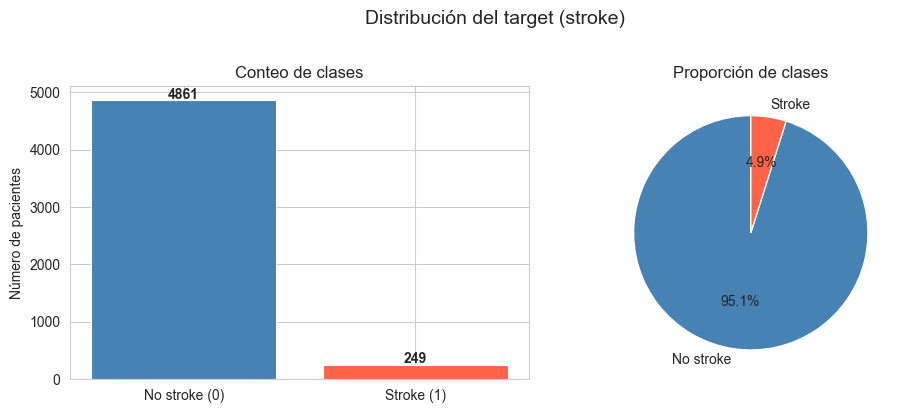

Ratio de desbalanceo: 19.5:1


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteo absoluto
counts = df["stroke"].value_counts()
axes[0].bar(["No stroke (0)", "Stroke (1)"], counts.values,
            color=["steelblue", "tomato"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Conteo de clases")
axes[0].set_ylabel("Número de pacientes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Proporción
axes[1].pie(counts.values, labels=["No stroke", "Stroke"],
            autopct="%1.1f%%", colors=["steelblue", "tomato"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporción de clases")

plt.suptitle("Distribución del target (stroke)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Ratio de desbalanceo: {counts[0]/counts[1]:.1f}:1")

### Nulos
Única columna con nulos es BMI

In [104]:
# Explorar si los nulos de bmi tienen algún patrón
print("Distribución de stroke en filas CON nulos en bmi:")
print(df[df["bmi"].isnull()]["stroke"].value_counts(normalize=True).round(3))
print("\nDistribución de stroke en filas SIN nulos:")
print(df[df["bmi"].notna()]["stroke"].value_counts(normalize=True).round(3))

Distribución de stroke en filas CON nulos en bmi:
stroke
0    0.801
1    0.199
Name: proportion, dtype: float64

Distribución de stroke en filas SIN nulos:
stroke
0    0.957
1    0.043
Name: proportion, dtype: float64


## 2. ✂️ Train / test split

> Se separa el dataset en entrenamiento y validación, manteniendo la proporción de la variable objetivo (*stratified split*). Esto es clave para evitar sesgos y asegurar una evaluación justa del modelo.


In [105]:
# ---
# 🔀 Split de datos en entrenamiento y validación
# Se utiliza stratify para mantener la proporción de casos de stroke en ambos sets
X = df.drop(columns="stroke")
y = df["stroke"].astype(int)

X_train, X_aux, y_train, y_aux = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_aux, y_aux,
    test_size=0.5,
    stratify=y_aux,
    random_state=42
)

split_summary = pd.DataFrame({
    "set": ["Train", "Test", "Val"],
    "rows": [len(X_train), len(X_test), len(X_val)],
    "stroke_rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2),
        round(y_val.mean() * 100, 2)
    ]
})

print("Split summary:")
display(split_summary)


Split summary:


,set,rows,stroke_rate (%)
0,Train,3066,4.86
1,Test,1022,4.89
2,Val,1022,4.89


In [106]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3066 entries, 3135 to 5052
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             3066 non-null   object 
 1   age                3066 non-null   float64
 2   hypertension       3066 non-null   int64  
 3   heart_disease      3066 non-null   int64  
 4   ever_married       3066 non-null   object 
 5   work_type          3066 non-null   object 
 6   Residence_type     3066 non-null   object 
 7   avg_glucose_level  3066 non-null   float64
 8   bmi                2939 non-null   float64
 9   smoking_status     3066 non-null   object 
dtypes: float64(3), int64(2), object(5)
memory usage: 263.5+ KB


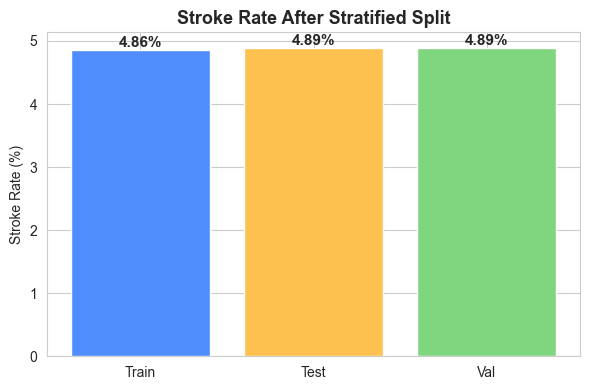


🔎 KEY OBSERVATIONS
- Train size: 3066 | Test size: 1022 | Val size: 1022
- Stroke rate (train): 4.86%
- Stroke rate (test):  4.89%
- Stroke rate (val):   4.89%
- El split estratificado preserva la distribución de clases en los tres sets.


In [107]:
# ---
# 📊 Visualización de la proporción de stroke tras el split
plt.figure(figsize=(6, 4))

split_rates = [y_train.mean() * 100, y_test.mean() * 100, y_val.mean() * 100]
labels = ["Train", "Test", "Val"]

bars = plt.bar(labels, split_rates, color=["#4F8DFD", "#FDC14F", "#7FD67F"])
plt.title("Stroke Rate After Stratified Split", fontsize=13, fontweight="bold")
plt.ylabel("Stroke Rate (%)")

for bar, val in zip(bars, split_rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🔎 KEY OBSERVATIONS")
print("=" * 60)
print(f"- Train size: {len(X_train)} | Test size: {len(X_test)} | Val size: {len(X_val)}")
print(f"- Stroke rate (train): {y_train.mean()*100:.2f}%")
print(f"- Stroke rate (test):  {y_test.mean()*100:.2f}%")
print(f"- Stroke rate (val):   {y_val.mean()*100:.2f}%")
print("- El split estratificado preserva la distribución de clases en los tres sets.")


## 3. 🧩 Tipado de variables y EDA sobre entrenamiento

> Todo el análisis exploratorio se realiza **solo sobre el set de entrenamiento** para evitar *leakage* de información hacia la validación.


In [108]:
# Feature typing
num_cols = ["age", "avg_glucose_level", "bmi"]

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status", "hypertension", "heart_disease"]

print("Numerical variables:", num_cols)
print("Categorical variables:", cat_cols)

Numerical variables: ['age', 'avg_glucose_level', 'bmi']
Categorical variables: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']


### 3.1 Variables numéricas — distribuciones y outliers


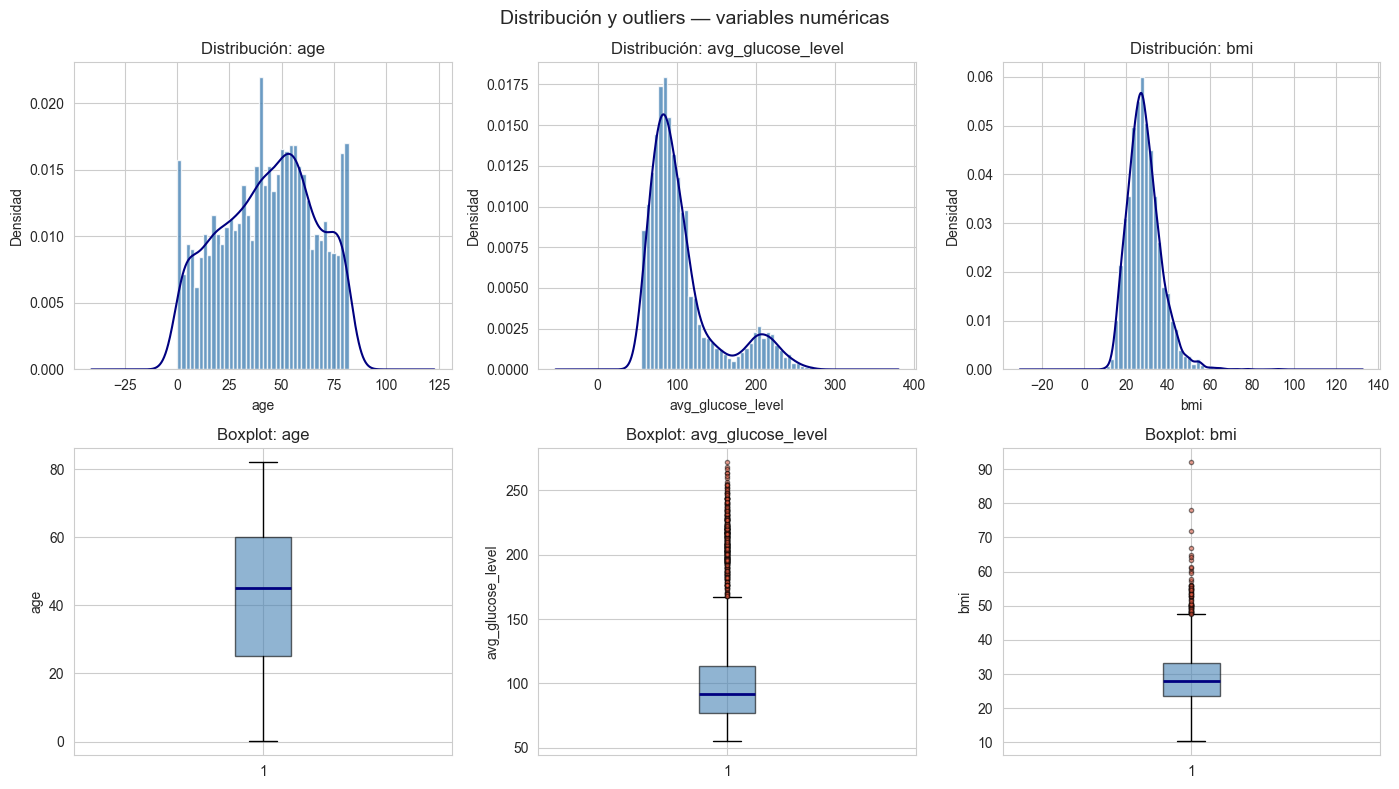

age                  → skewness: -0.135
avg_glucose_level    → skewness: 1.583
bmi                  → skewness: 1.051


In [109]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Histograma + KDE
    axes[0, i].hist(X_train[col].dropna(), bins=40, color="steelblue",
                    edgecolor="white", alpha=0.8, density=True)
    X_train[col].dropna().plot(kind="kde", ax=axes[0, i], color="navy", linewidth=1.5)
    axes[0, i].set_title(f"Distribución: {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Densidad")

    # Boxplot para detectar outliers
    axes[1, i].boxplot(X_train[col].dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor="steelblue", alpha=0.6),
                       medianprops=dict(color="navy", linewidth=2),
                       flierprops=dict(marker="o", markersize=3,
                                       markerfacecolor="tomato", alpha=0.5))
    axes[1, i].set_title(f"Boxplot: {col}")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución y outliers — variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas de skewness
for col in num_cols:
    skew = X_train[col].skew()
    print(f"{col:20s} → skewness: {skew:.3f}")

### 3.2 Variables categóricas — distribuciones


/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/2373118661.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
/var/folders/6s/4bx

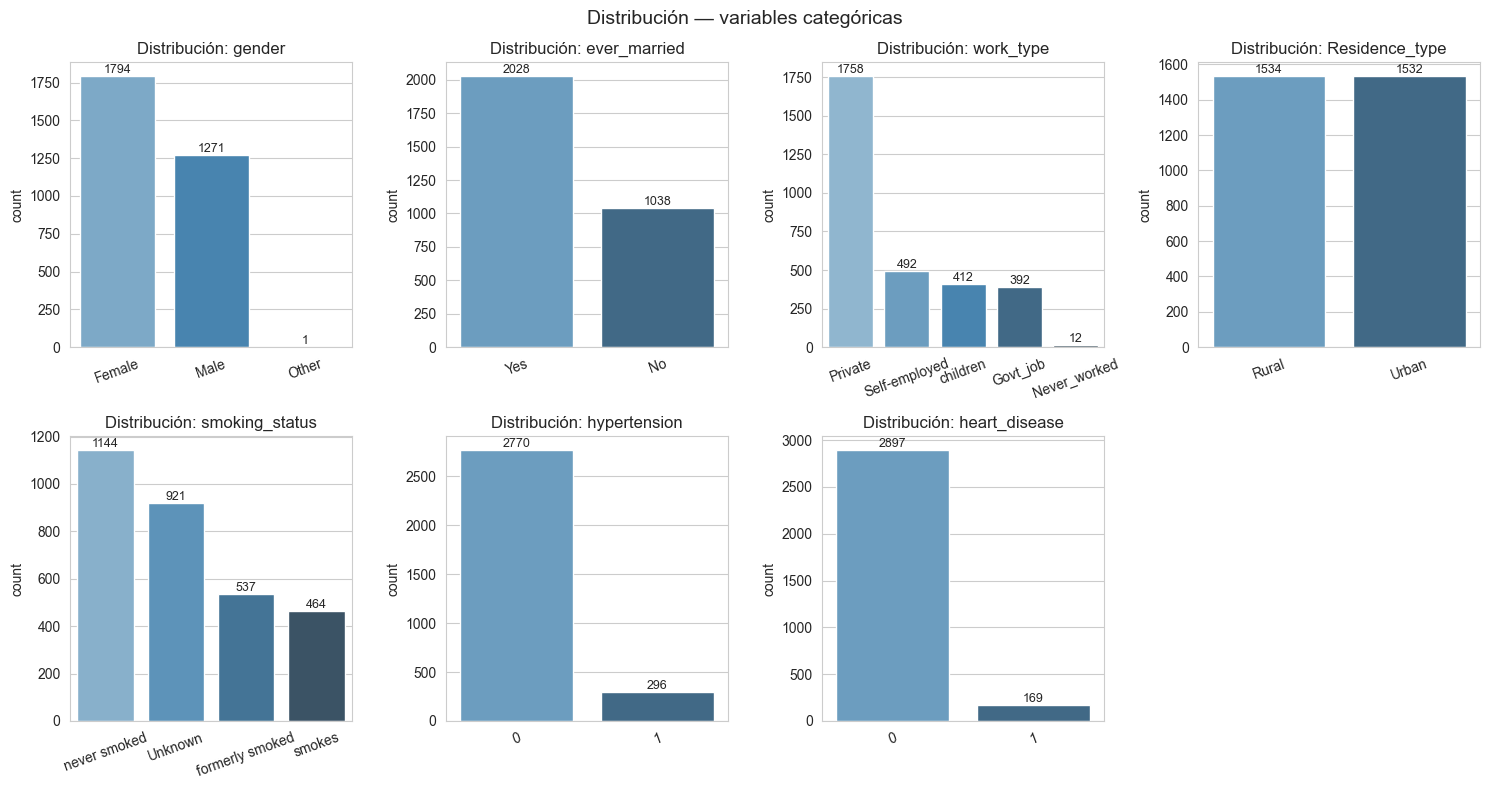

In [110]:

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = X_train[col].value_counts().index
    sns.countplot(data=X_train, x=col, order=order, ax=axes[i],
                  palette="Blues_d", edgecolor="white")
    axes[i].set_title(f"Distribución: {col}")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=20)
    # Anotar conteos
    for p in axes[i].patches:
        axes[i].annotate(f"{int(p.get_height())}",
                         (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha="center", va="bottom", fontsize=9)

axes[-1].set_visible(False)  # Ocultar el subplot sobrante
plt.suptitle("Distribución — variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Variables vs target en el set de entrenamiento


### Variables numéricas


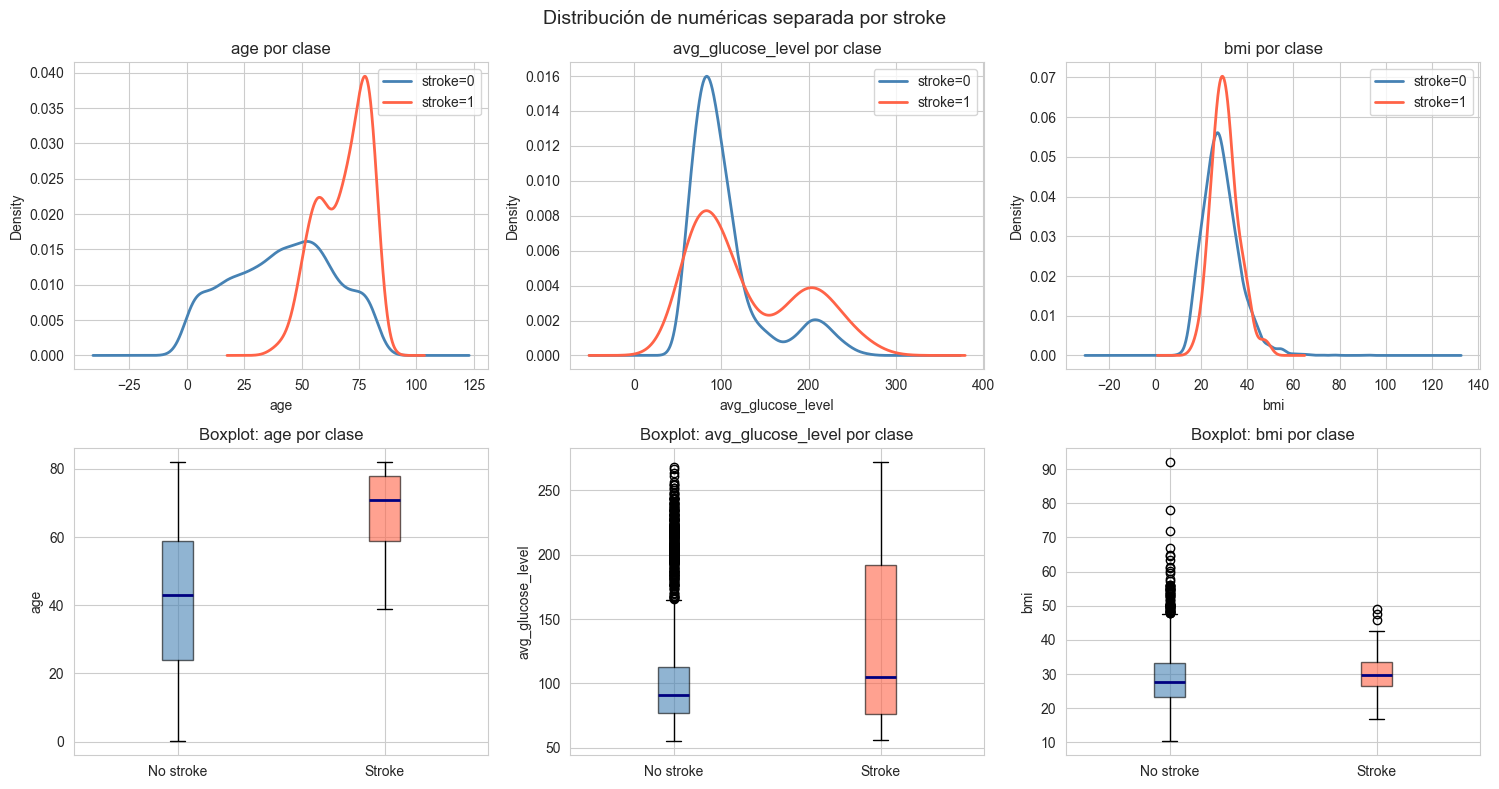

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # KDE separado por clase
    for label, color in zip([0, 1], ["steelblue", "tomato"]):
        subset = X_train[y_train == label][col].dropna()
        subset.plot(kind="kde", ax=axes[0, i], label=f"stroke={label}",
                    color=color, linewidth=2)
    axes[0, i].set_title(f"{col} por clase")
    axes[0, i].set_xlabel(col)
    axes[0, i].legend()

    # Boxplot por clase
    data_by_class = [X_train[y_train == lbl][col].dropna() for lbl in [0, 1]]
    bp = axes[1, i].boxplot(data_by_class, labels=["No stroke", "Stroke"],
                            patch_artist=True,
                            medianprops=dict(color="navy", linewidth=2))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][0].set_alpha(0.6)
    bp["boxes"][1].set_facecolor("tomato")
    bp["boxes"][1].set_alpha(0.6)
    axes[1, i].set_title(f"Boxplot: {col} por clase")
    axes[1, i].set_ylabel(col)

plt.suptitle("Distribución de numéricas separada por stroke", fontsize=14)
plt.tight_layout()
plt.show()

- Age vs stroke: Claramente desplazado hacia edades más altas. La edad es el predictor más fuerte del dataset.
- Nivel de glucosa vs stroke: casos de stroke = 1 tiene mayor densida en valores altos de glucosa.
- BMI vs stroke: No es un predictor fuerte del dataset.

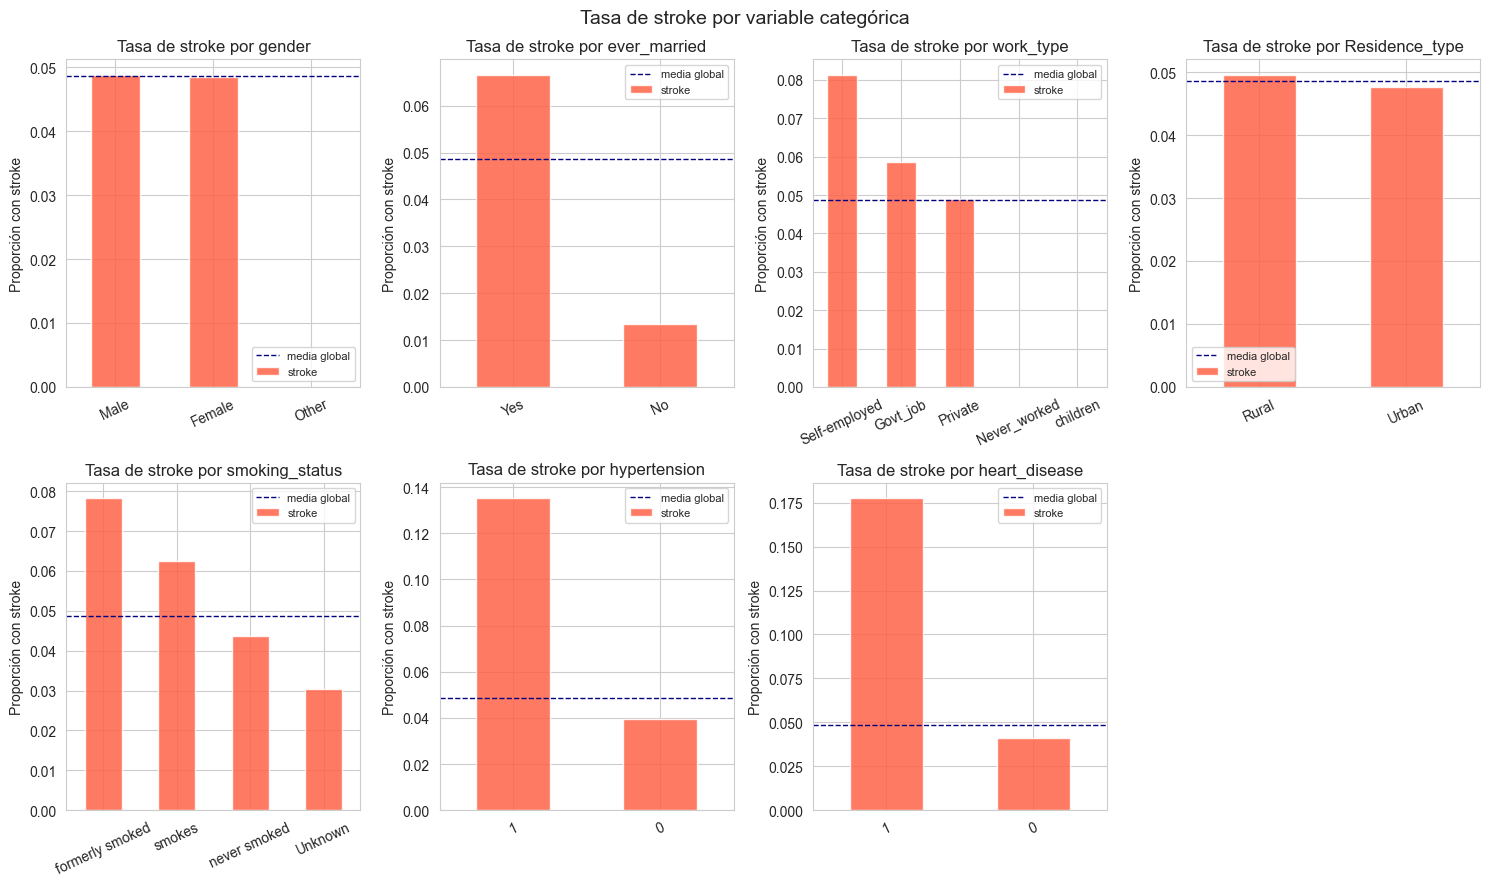

In [112]:
# --- Categóricas vs target: tasa de stroke por categoría ---
fig, axes = plt.subplots(2, 4, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stroke_rate = y_train.groupby(X_train[col]).mean().sort_values(ascending=False)  
    stroke_rate.plot(kind="bar", ax=axes[i], color="tomato",
                     edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Tasa de stroke por {col}")
    axes[i].set_ylabel("Proporción con stroke")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].axhline(y_train.mean(), color="navy",
                    linestyle="--", linewidth=1, label="media global")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Tasa de stroke por variable categórica", fontsize=14)
plt.tight_layout()
plt.show()

- Hypertension y heart_disease tienen una tasa de stroke notablemente más altas que la media global.
- smoking_status con el valor de formerly_smoked tambien cuenta una tasa de stroke un poco mas alta que la media global.
- work_type con el valor de self_employed tambien presenta una tasa de stroke un poco mas alta que la media global.

### Correlaciones entre features

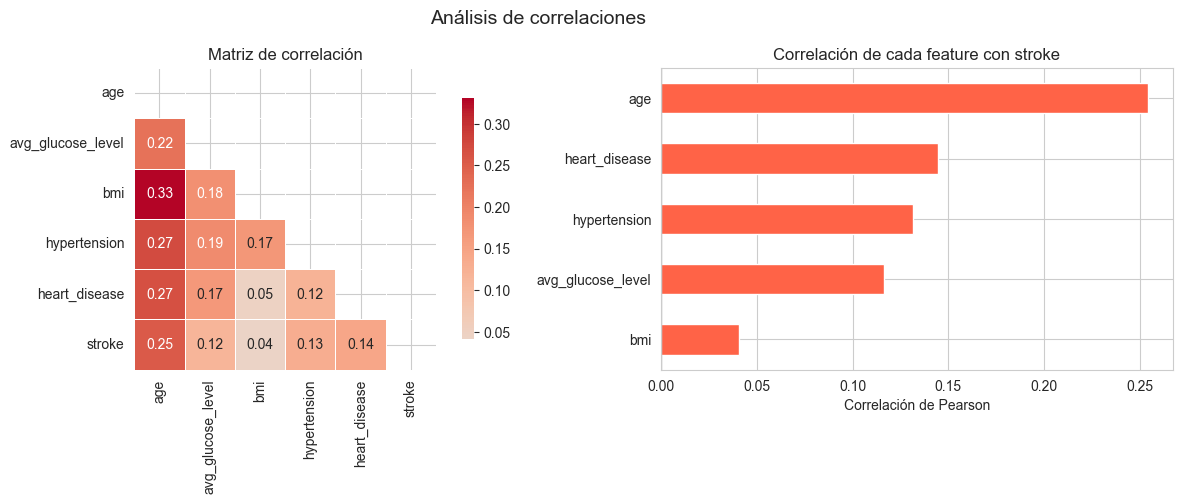

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))                                                                                 
                                                                                                                                                                                                                                                   
corr_df_eda = X_train[["age", "avg_glucose_level", "bmi", "hypertension",                                                                                                                                                                           
                    "heart_disease"]].copy()                                                                                                                                                                                                    
corr_df_eda["stroke"] = y_train.values                                                                                                                                                                                                              
                                                                                                                                                                                                                                                
corr = corr_df_eda.corr()
                                                                                                                                                                                                                                                
mask = np.triu(np.ones_like(corr, dtype=bool))            
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], square=True,                                                                                                                                                                                                   
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("Matriz de correlación")                                                                                                                                                                                                       
                                                                                                                                                                                                                                                
target_corr = corr["stroke"].drop("stroke").sort_values(key=abs, ascending=True)
target_corr.plot(kind="barh", ax=axes[1],                                                                                                                                                                                                        
                color=["tomato" if v > 0 else "steelblue" for v in target_corr],
                edgecolor="white")                                                                                                                                                                                                              
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de cada feature con stroke")                                                                                                                                                                                      
axes[1].set_xlabel("Correlación de Pearson")              
                                                                                                                                                                                                                                                
plt.suptitle("Análisis de correlaciones", fontsize=14)
plt.tight_layout()                                                                                                                                                                                                                               
plt.show()

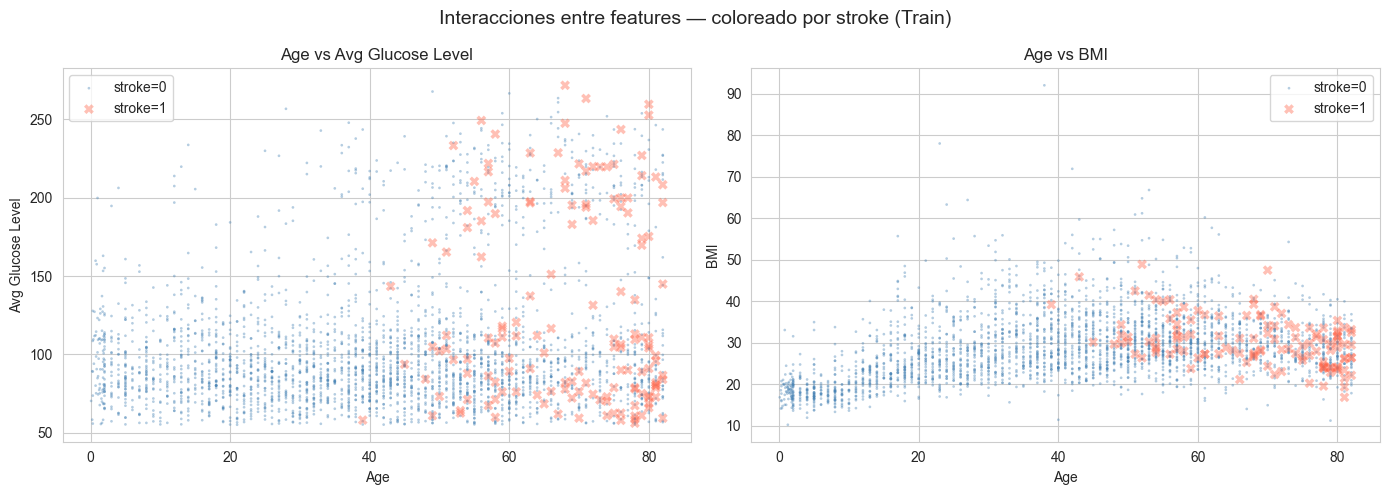

Observaciones:
  - Los casos de stroke se concentran en edades mayores (>40 años)
  - Glucosa alta + edad avanzada parece ser un patrón frecuente en stroke
  - El BMI solo no discrimina bien, pero combinado con edad aporta información


In [114]:
# --- Interacciones clave entre features (Train) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age vs Avg Glucose Level
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = X_train[y_train == label]
    axes[0].scatter(subset["age"], subset["avg_glucose_level"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Avg Glucose Level")
axes[0].set_title("Age vs Avg Glucose Level")
axes[0].legend()

# Age vs BMI
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = X_train[y_train == label]
    axes[1].scatter(subset["age"], subset["bmi"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("BMI")
axes[1].set_title("Age vs BMI")
axes[1].legend()

plt.suptitle("Interacciones entre features — coloreado por stroke (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("  - Los casos de stroke se concentran en edades mayores (>40 años)")
print("  - Glucosa alta + edad avanzada parece ser un patrón frecuente en stroke")
print("  - El BMI solo no discrimina bien, pero combinado con edad aporta información")

- Age presenta la correlación más alta con stroke. Al mismo tiempo presenta una correlación alta con hypertension y heart_disease. Lo que indica cierta multicolinealidad entre features. 

## 4. Análisis de `smoking_status = "Unknown"`

Esta sección explora si `"Unknown"` se comporta como una categoría propia o podría agruparse con otra categoría de tabaquismo.


In [115]:
# --- Proporción y conteo de Unknown en train ---
smoking_counts = X_train["smoking_status"].value_counts()
smoking_pct = X_train["smoking_status"].value_counts(normalize=True)

summary_smoking = pd.DataFrame({"conteo": smoking_counts, "proporción": smoking_pct.round(4)})
display(summary_smoking)

n_unknown = (X_train["smoking_status"] == "Unknown").sum()
print(f"\n'Unknown' representa {n_unknown} filas ({n_unknown/len(X_train):.1%} del train set)")
print(f"No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.")

,conteo,proporción
smoking_status,,
never smoked,1144,0.3731
Unknown,921,0.3004
formerly smoked,537,0.1751
smokes,464,0.1513



'Unknown' representa 921 filas (30.0% del train set)
No es un nulo técnico (no aparece en isnull), sino un valor explícito del dataset.


/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/151067315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=X_train, x="smoking_status", y="age", ax=axes[0, 0],


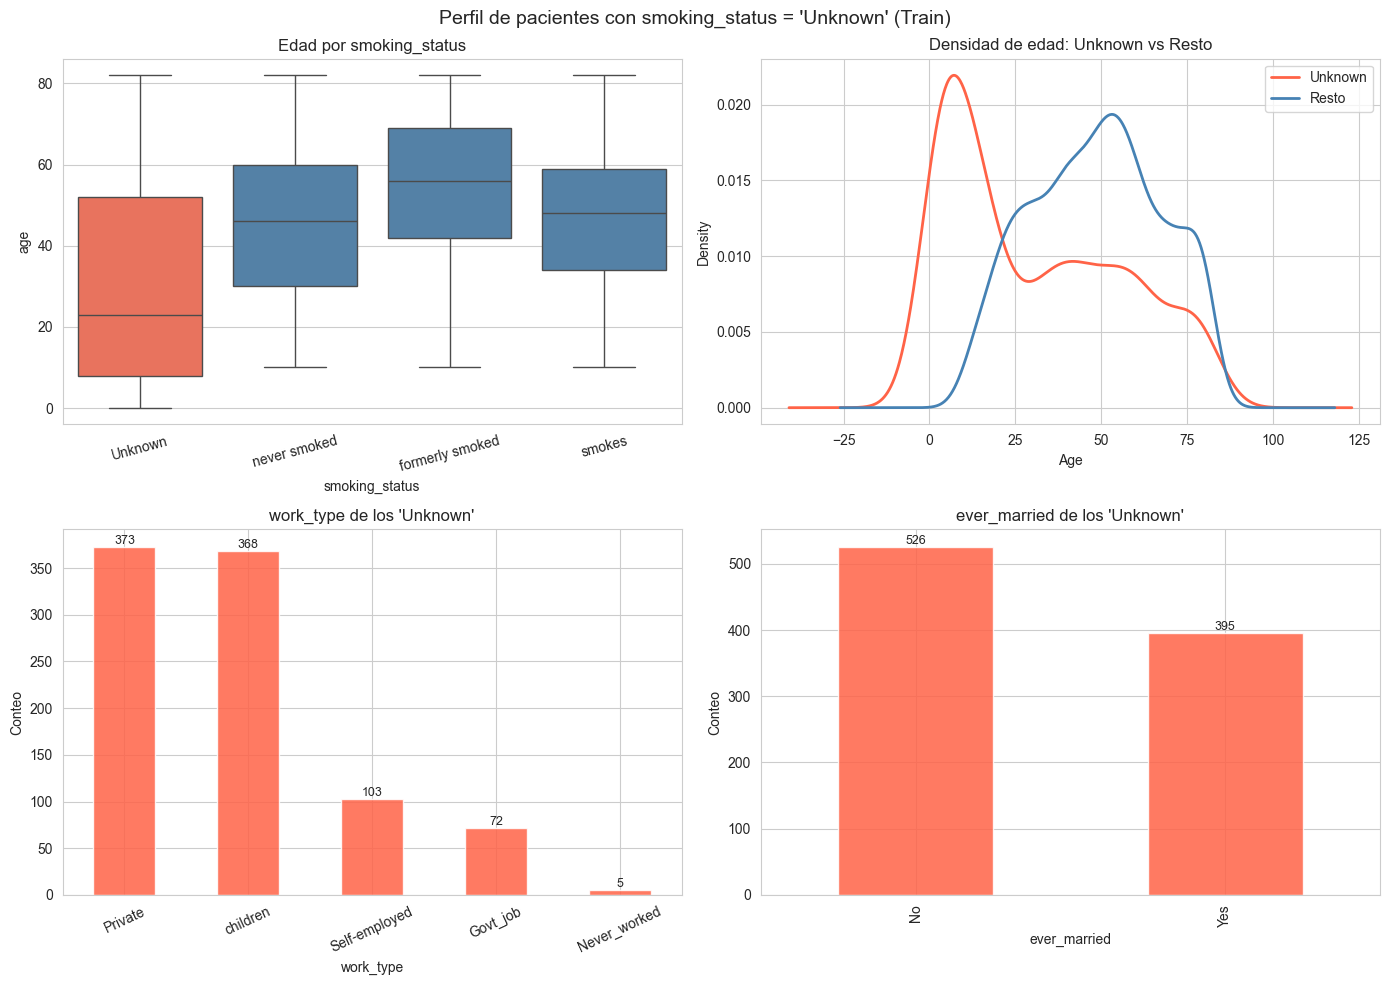

Edad media por smoking_status:
                 mean  median   min   max
smoking_status                           
Unknown          30.5    23.0   0.1  82.0
formerly smoked  54.5    56.0  10.0  82.0
never smoked     46.0    46.0  10.0  82.0
smokes           47.8    48.0  10.0  82.0

% de menores de 18 años dentro de Unknown: 44.1%


In [116]:
# --- Perfil demográfico de Unknown vs otras categorías ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de edad por smoking_status
sns.boxplot(data=X_train, x="smoking_status", y="age", ax=axes[0, 0],
            order=["Unknown", "never smoked", "formerly smoked", "smokes"],
            palette={"Unknown": "tomato", "never smoked": "steelblue",
                     "formerly smoked": "steelblue", "smokes": "steelblue"})
axes[0, 0].set_title("Edad por smoking_status")
axes[0, 0].tick_params(axis="x", rotation=15)

# 2. Distribución de edad: KDE Unknown vs resto
X_train[X_train["smoking_status"] == "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Unknown", color="tomato", linewidth=2)
X_train[X_train["smoking_status"] != "Unknown"]["age"].plot(
    kind="kde", ax=axes[0, 1], label="Resto", color="steelblue", linewidth=2)
axes[0, 1].set_title("Densidad de edad: Unknown vs Resto")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# 3. Work type dentro de Unknown
unknown_work = X_train[X_train["smoking_status"] == "Unknown"]["work_type"].value_counts()
unknown_work.plot(kind="bar", ax=axes[1, 0], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 0].set_title("work_type de los 'Unknown'")
axes[1, 0].set_ylabel("Conteo")
axes[1, 0].tick_params(axis="x", rotation=25)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# 4. ever_married dentro de Unknown
unknown_married = X_train[X_train["smoking_status"] == "Unknown"]["ever_married"].value_counts()
unknown_married.plot(kind="bar", ax=axes[1, 1], color="tomato", edgecolor="white", alpha=0.85)
axes[1, 1].set_title("ever_married de los 'Unknown'")
axes[1, 1].set_ylabel("Conteo")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{int(p.get_height())}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

plt.suptitle("Perfil de pacientes con smoking_status = 'Unknown' (Train)", fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas numéricas
print("Edad media por smoking_status:")
print(X_train.groupby("smoking_status")["age"].agg(["mean", "median", "min", "max"]).round(1))
print(f"\n% de menores de 18 años dentro de Unknown: "
      f"{(X_train[X_train['smoking_status']=='Unknown']['age'] < 18).mean():.1%}")

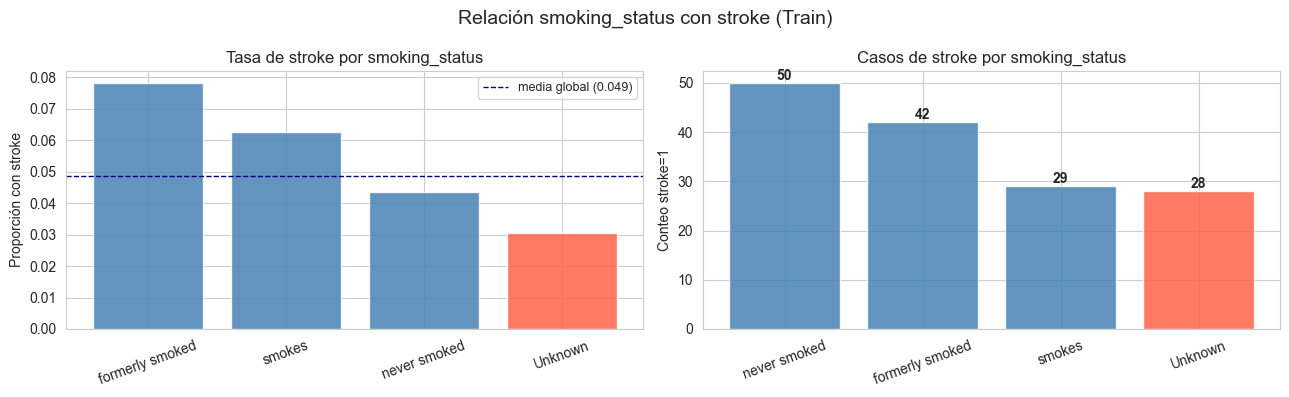

Tasa de stroke y conteo por categoría:


,tasa_stroke,n_stroke,n_total
smoking_status,,,
formerly smoked,0.078212,42,537
smokes,0.062500,29,464
never smoked,0.043706,50,1144
Unknown,0.030402,28,921


In [117]:
# --- Tasa de stroke: Unknown vs otras categorías ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tasa de stroke por smoking_status
stroke_by_smoking = y_train.groupby(X_train["smoking_status"]).agg(["mean", "count"])
stroke_by_smoking = stroke_by_smoking.sort_values("mean", ascending=False)

colors = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_by_smoking.index]
axes[0].bar(stroke_by_smoking.index, stroke_by_smoking["mean"], color=colors,
            edgecolor="white", alpha=0.85)
axes[0].axhline(y_train.mean(), color="navy", linestyle="--",
                linewidth=1, label=f"media global ({y_train.mean():.3f})")
axes[0].set_title("Tasa de stroke por smoking_status")
axes[0].set_ylabel("Proporción con stroke")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=9)

# Conteo de stroke=1 por smoking_status
stroke_counts = X_train[y_train == 1]["smoking_status"].value_counts()
colors2 = ["tomato" if idx == "Unknown" else "steelblue" for idx in stroke_counts.index]
axes[1].bar(stroke_counts.index, stroke_counts.values, color=colors2,
            edgecolor="white", alpha=0.85)
axes[1].set_title("Casos de stroke por smoking_status")
axes[1].set_ylabel("Conteo stroke=1")
axes[1].tick_params(axis="x", rotation=20)
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Relación smoking_status con stroke (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Tasa de stroke y conteo por categoría:")
display(y_train.groupby(X_train["smoking_status"]).agg(["mean", "sum", "count"])
        .rename(columns={"mean": "tasa_stroke", "sum": "n_stroke", "count": "n_total"})
        .sort_values("tasa_stroke", ascending=False))

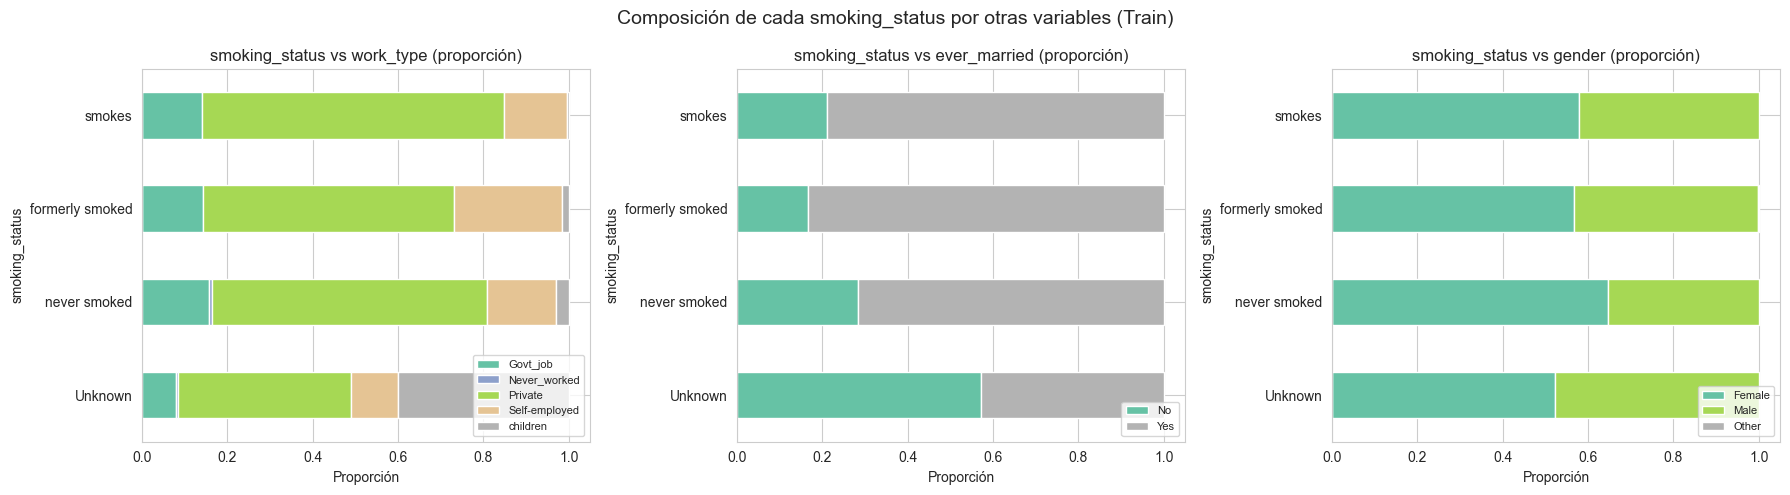

In [118]:
# --- Crosstab: smoking_status vs otras categóricas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["work_type", "ever_married", "gender"]):
    ct = pd.crosstab(X_train["smoking_status"], X_train[col], normalize="index")
    ct.loc[["Unknown", "never smoked", "formerly smoked", "smokes"]].plot(
        kind="barh", stacked=True, ax=ax, colormap="Set2", edgecolor="white")
    ax.set_title(f"smoking_status vs {col} (proporción)")
    ax.set_xlabel("Proporción")
    ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Composición de cada smoking_status por otras variables (Train)", fontsize=14)
plt.tight_layout()
plt.show()

In [119]:
# --- Resumen: ¿quiénes son los Unknown? ---
unknown = X_train[X_train["smoking_status"] == "Unknown"]
known = X_train[X_train["smoking_status"] != "Unknown"]
y_unknown = y_train[X_train["smoking_status"] == "Unknown"]
y_known = y_train[X_train["smoking_status"] != "Unknown"]

resumen = pd.DataFrame({
    "Unknown": [
        len(unknown),
        unknown["age"].mean(),
        unknown["age"].median(),
        (unknown["age"] < 18).mean(),
        (unknown["work_type"] == "children").mean(),
        (unknown["ever_married"] == "No").mean(),
        y_unknown.mean(),
    ],
    "Resto": [
        len(known),
        known["age"].mean(),
        known["age"].median(),
        (known["age"] < 18).mean(),
        (known["work_type"] == "children").mean(),
        (known["ever_married"] == "No").mean(),
        y_known.mean(),
    ]
}, index=["N", "Edad media", "Edad mediana", "% menores 18",
          "% work_type=children", "% ever_married=No", "Tasa de stroke"])

display(resumen.round(4))


,Unknown,Resto
N,921.0000,2145.0000
Edad media,30.5387,48.5329
Edad mediana,23.0000,49.0000
% menores 18,0.4408,0.0443
% work_type=children,0.3996,0.0205
% ever_married=No,0.5711,0.2387
Tasa de stroke,0.0304,0.0564



- Los 'Unknown' son mayoritariamente personas jóvenes (niños/adolescentes). Muchos tienen work_type='children' y ever_married='No'
- Su baja tasa de stroke se explica por la edad, no por el hábito de fumar
- 'Unknown' NO es dato faltante aleatorio (MCAR), sino sistemático (MAR). Está asociado a la edad del paciente

Opciones de tratamiento:
- Mantener 'Unknown' como categoría propia. Refleja información real, no aplica.
- Reemplazar por 'never smoked' en menores de 18 y dejar Unknown en adultos
- Imputar con modelo predictivo basado en age, work_type, ever_married

### Decisión de preprocesamiento para `smoking_status`

Se reemplaza `"Unknown"` por `"never smoked"` en ambos sets (train y test).


In [120]:
# Smoking_status replacement
X_train["smoking_status"] = X_train["smoking_status"].replace("Unknown", "never smoked")
X_test["smoking_status"]  = X_test["smoking_status"].replace("Unknown", "never smoked")
X_val["smoking_status"]   = X_val["smoking_status"].replace("Unknown", "never smoked")


## 5. Análisis de valores faltantes en `bmi`

In [121]:
# --- Proporción y conteo de nulos en BMI ---
bmi_missing = X_train["bmi"].isnull()
n_missing = bmi_missing.sum()
pct_missing = bmi_missing.mean() * 100

print(f"BMI faltante: {n_missing} filas ({pct_missing:.2f}% del train set)")
print(f"BMI presente: {(~bmi_missing).sum()} filas ({100 - pct_missing:.2f}%)")
print(f"\nEs la única columna con nulos en el dataset.")

BMI faltante: 127 filas (4.14% del train set)
BMI presente: 2939 filas (95.86%)

Es la única columna con nulos en el dataset.


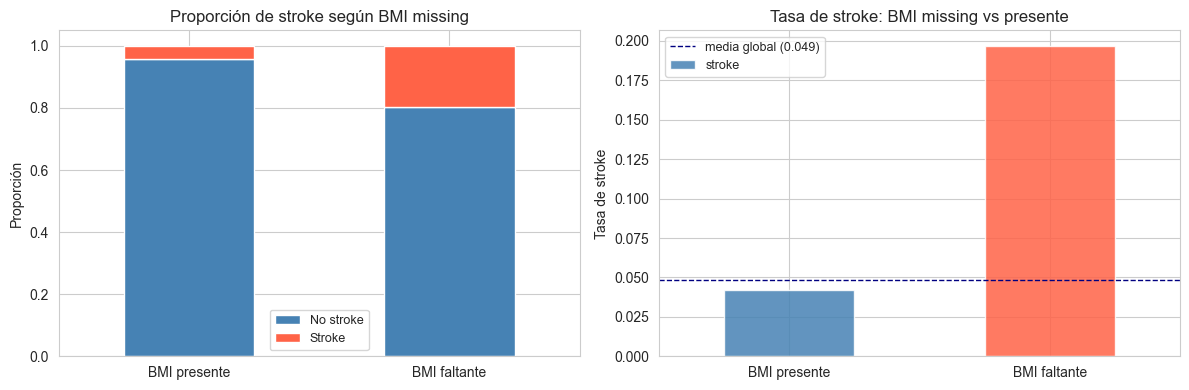

Tasa de stroke por grupo:
  BMI presente: 0.0422
  BMI faltante: 0.1969


In [122]:
# --- ¿Los nulos de BMI están asociados al target? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bmi_missing_flag = X_train["bmi"].isnull().astype(int)

# 1. Crosstab normalizado
ctab = pd.crosstab(bmi_missing_flag, y_train, normalize="index")
ctab.index = ["BMI presente", "BMI faltante"]
ctab = ctab.rename(columns={0: "No stroke", 1: "Stroke"})
ctab.plot(kind="bar", stacked=True, ax=axes[0],
          color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Proporción de stroke según BMI missing")
axes[0].set_ylabel("Proporción")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(fontsize=9)

# 2. Tasa de stroke: missing vs presente
stroke_rate = y_train.groupby(bmi_missing_flag).mean()
stroke_rate.index = ["BMI presente", "BMI faltante"]
colors = ["steelblue", "tomato"]
stroke_rate.plot(kind="bar", ax=axes[1], color=colors, edgecolor="white", alpha=0.85)
axes[1].axhline(y_train.mean(), color="navy", linestyle="--",
                linewidth=1, label=f"media global ({y_train.mean():.3f})")
axes[1].set_title("Tasa de stroke: BMI missing vs presente")
axes[1].set_ylabel("Tasa de stroke")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Tasa de stroke por grupo:")
print(f"  BMI presente: {y_train[~X_train["bmi"].isnull()].mean():.4f}")
print(f"  BMI faltante: {y_train[X_train["bmi"].isnull()].mean():.4f}")

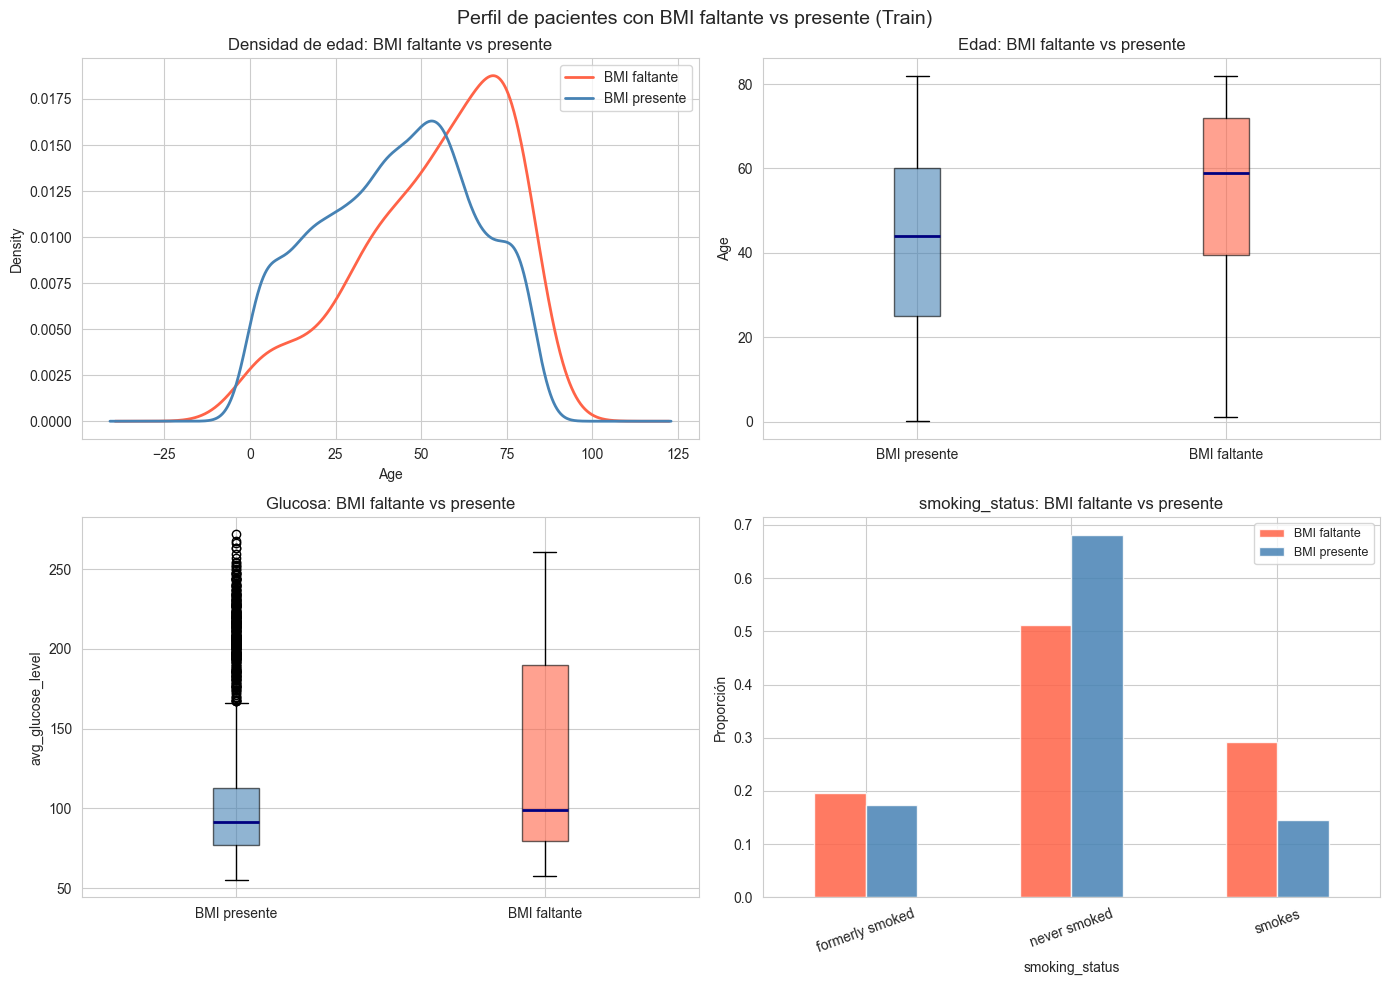

Edad media por grupo:
  BMI presente: 42.7 años
  BMI faltante: 53.5 años


In [123]:
# --- Perfil demográfico: BMI faltante vs presente ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

bmi_missing_flag = X_train["bmi"].isnull()

# 1. Distribución de edad: KDE missing vs presente
X_train[bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI faltante", color="tomato", linewidth=2)
X_train[~bmi_missing_flag]["age"].plot(
    kind="kde", ax=axes[0, 0], label="BMI presente", color="steelblue", linewidth=2)
axes[0, 0].set_title("Densidad de edad: BMI faltante vs presente")
axes[0, 0].set_xlabel("Age")
axes[0, 0].legend()

# 2. Boxplot de edad por BMI missing
data_age = [X_train[~bmi_missing_flag]["age"], X_train[bmi_missing_flag]["age"]]
bp = axes[0, 1].boxplot(data_age, labels=["BMI presente", "BMI faltante"],
                        patch_artist=True, medianprops=dict(color="navy", linewidth=2))
bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][0].set_alpha(0.6)
bp["boxes"][1].set_facecolor("tomato"); bp["boxes"][1].set_alpha(0.6)
axes[0, 1].set_title("Edad: BMI faltante vs presente")
axes[0, 1].set_ylabel("Age")

# 3. Glucosa por BMI missing
data_gluc = [X_train[~bmi_missing_flag]["avg_glucose_level"],
             X_train[bmi_missing_flag]["avg_glucose_level"]]
bp2 = axes[1, 0].boxplot(data_gluc, labels=["BMI presente", "BMI faltante"],
                         patch_artist=True, medianprops=dict(color="navy", linewidth=2))
bp2["boxes"][0].set_facecolor("steelblue"); bp2["boxes"][0].set_alpha(0.6)
bp2["boxes"][1].set_facecolor("tomato"); bp2["boxes"][1].set_alpha(0.6)
axes[1, 0].set_title("Glucosa: BMI faltante vs presente")
axes[1, 0].set_ylabel("avg_glucose_level")

# 4. Distribución de categóricas en BMI faltante
missing_cats = X_train[bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
present_cats = X_train[~bmi_missing_flag]["smoking_status"].value_counts(normalize=True)
compare = pd.DataFrame({"BMI faltante": missing_cats, "BMI presente": present_cats})
compare.plot(kind="bar", ax=axes[1, 1], color=["tomato", "steelblue"],
             edgecolor="white", alpha=0.85)
axes[1, 1].set_title("smoking_status: BMI faltante vs presente")
axes[1, 1].set_ylabel("Proporción")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].legend(fontsize=9)

plt.suptitle("Perfil de pacientes con BMI faltante vs presente (Train)", fontsize=14)
plt.tight_layout()
plt.show()

print("Edad media por grupo:")
print(f"  BMI presente: {X_train[~bmi_missing_flag]["age"].mean():.1f} años")
print(f"  BMI faltante: {X_train[bmi_missing_flag]["age"].mean():.1f} años")

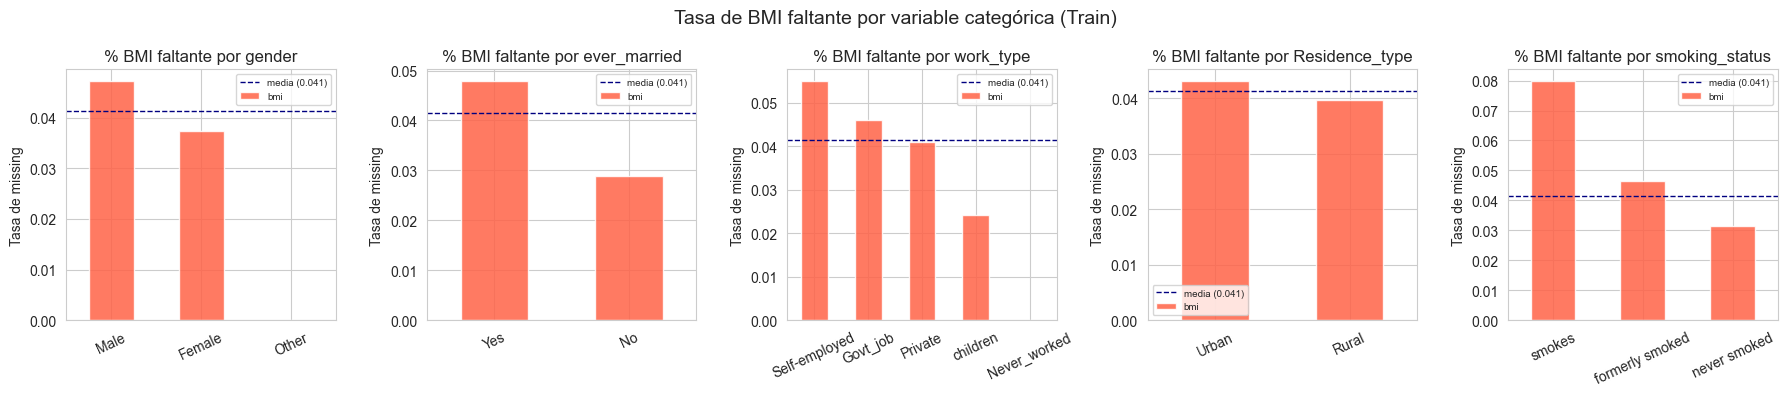

In [124]:
# --- Tasa de BMI faltante por variable categórica ---
bmi_missing_flag = X_train["bmi"].isnull().astype(int)
cat_check = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

fig, axes = plt.subplots(1, len(cat_check), figsize=(18, 4))

for i, col in enumerate(cat_check):
    rate = bmi_missing_flag.groupby(X_train[col]).mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=axes[i], color="tomato", edgecolor="white", alpha=0.85)
    axes[i].axhline(bmi_missing_flag.mean(), color="navy", linestyle="--",
                    linewidth=1, label=f"media ({bmi_missing_flag.mean():.3f})")
    axes[i].set_title(f"% BMI faltante por {col}")
    axes[i].set_ylabel("Tasa de missing")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=25)
    axes[i].legend(fontsize=7)

plt.suptitle("Tasa de BMI faltante por variable categórica (Train)", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/1795190907.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])


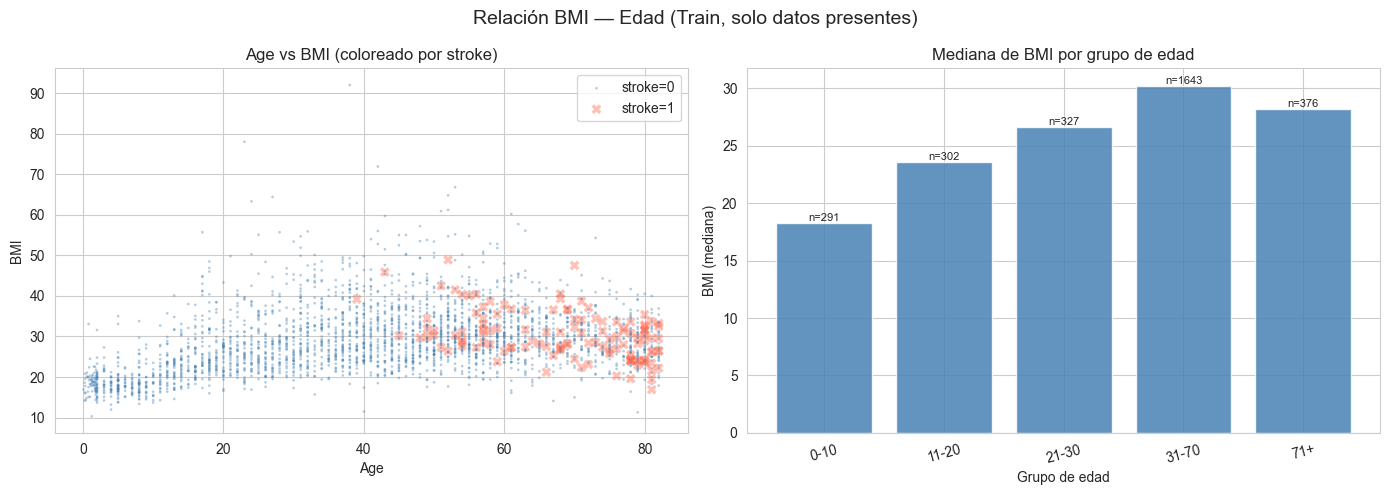

Mediana de BMI por grupo de edad:


,median,mean,count
age_group_temp,,,
0-10,18.3,18.75,291
11-20,23.6,25.14,302
21-30,26.6,28.34,327
31-70,30.2,31.46,1643
71+,28.2,28.66,376


In [125]:
# --- Relación BMI vs Edad (solo datos presentes) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_complete = X_train[X_train["bmi"].notna()].copy()
y_complete = y_train[X_train["bmi"].notna()]

# 1. Scatter age vs BMI coloreado por stroke
for label, color, marker in zip([0, 1], ["steelblue", "tomato"], [".", "X"]):
    subset = train_complete[y_complete == label]
    axes[0].scatter(subset["age"], subset["bmi"],
                    c=color, label=f"stroke={label}", alpha=0.4,
                    s=15 if label == 0 else 50, marker=marker, edgecolors="none")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("BMI")
axes[0].set_title("Age vs BMI (coloreado por stroke)")
axes[0].legend()

# 2. Mediana de BMI por grupo de edad
age_bins = [0, 10, 20, 30, 70, np.inf]
age_labels = ["0-10", "11-20", "21-30", "31-70", "71+"]
train_complete["age_group_temp"] = pd.cut(train_complete["age"], bins=age_bins,
                                          labels=age_labels, include_lowest=True)
bmi_by_age = train_complete.groupby("age_group_temp")["bmi"].agg(["median", "mean", "count"])

bars = axes[1].bar(bmi_by_age.index, bmi_by_age["median"],
                   color="steelblue", edgecolor="white", alpha=0.85)
for bar, count in zip(bars, bmi_by_age["count"]):
    axes[1].annotate(f"n={count}",
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=8)
axes[1].set_title("Mediana de BMI por grupo de edad")
axes[1].set_ylabel("BMI (mediana)")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Relación BMI — Edad (Train, solo datos presentes)", fontsize=14)
plt.tight_layout()
plt.show()

print("Mediana de BMI por grupo de edad:")
display(bmi_by_age.round(2))

In [126]:
# --- Resumen: BMI faltante vs presente ---
bmi_missing_flag = X_train["bmi"].isnull()
missing = X_train[bmi_missing_flag]
present = X_train[~bmi_missing_flag]
y_missing = y_train[bmi_missing_flag]
y_present = y_train[~bmi_missing_flag]

resumen = pd.DataFrame({
    "BMI faltante": [
        len(missing),
        missing["age"].mean(),
        missing["age"].median(),
        missing["avg_glucose_level"].mean(),
        (missing["ever_married"] == "No").mean(),
        y_missing.mean(),
    ],
    "BMI presente": [
        len(present),
        present["age"].mean(),
        present["age"].median(),
        present["avg_glucose_level"].mean(),
        (present["ever_married"] == "No").mean(),
        y_present.mean(),
    ]
}, index=["N", "Edad media", "Edad mediana", "Glucosa media",
          "% ever_married=No", "Tasa de stroke"])

display(resumen.round(4))


,BMI faltante,BMI presente
N,127.0000,2939.0000
Edad media,53.5449,42.6774
Edad mediana,59.0000,44.0000
Glucosa media,123.9623,105.0380
% ever_married=No,0.2362,0.3430
Tasa de stroke,0.1969,0.0422



  1. BMI faltante no parece estar fuertemente asociado al target (stroke)
  2. La distribución de edad entre missing y presente es similar
  3. BMI varía significativamente con la edad (niños tienen BMI mucho menor). Justifica imputar con la mediana por grupo de edad, no la mediana global
  4. El mecanismo de missing parece ser MAR (asociado a otras variables) o MCAR

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_22866/2136968489.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(


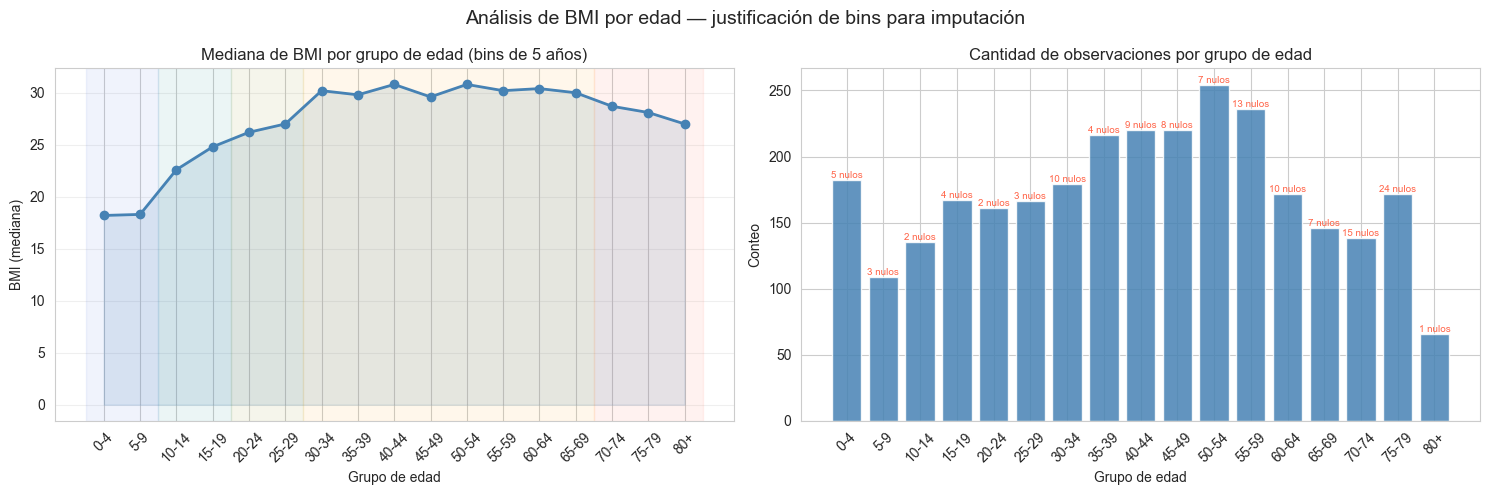

,mediana,media,conteo,nulos
age_fine,,,,
0-4,18.2,18.7,182,5
5-9,18.3,18.8,109,3
10-14,22.6,23.0,135,2
15-19,24.8,26.9,167,4
20-24,26.2,28.3,161,2
25-29,27.0,28.4,166,3
30-34,30.2,31.4,179,10
35-39,29.8,31.3,216,4
40-44,30.8,31.7,220,9



Observaciones:
  - 0-10 años: BMI bajo (~18), grupo claramente diferenciado
  - 10-20 años: salto importante (BMI 23→25), transición pubertad
  - 20-30 años: BMI intermedio (~27), aún en crecimiento
  - 30-70 años: meseta estable (BMI ~29-31), no justifica dividir en 4 bins
  - 70+ años: leve descenso (BMI ~28), mayor tasa de nulos

→ Bins propuestos para imputación: [0-10, 10-20, 20-30, 30-70, 70+]


In [127]:
# --- Justificación de bins de edad para imputación de BMI ---
# Analizamos la mediana de BMI con bins granulares de 5 años para
# identificar dónde hay saltos reales vs mesetas estables.

fine_bins = list(range(0, 85, 5)) + [np.inf]
fine_labels = [f"{b}-{fine_bins[i+1]-1}" if fine_bins[i+1] != np.inf else f"{b}+"
               for i, b in enumerate(fine_bins[:-1])]

train_bmi = X_train.copy()
train_bmi["age_fine"] = pd.cut(train_bmi["age"], bins=fine_bins,
                               labels=fine_labels, include_lowest=True)

bmi_stats = train_bmi.groupby("age_fine")["bmi"].agg(
    mediana="median", media="mean", conteo="count",
    nulos=lambda x: x.isnull().sum()
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Mediana de BMI por bin de 5 años
axes[0].plot(bmi_stats.index.astype(str), bmi_stats["mediana"],
             marker="o", color="steelblue", linewidth=2, markersize=6)
axes[0].fill_between(range(len(bmi_stats)), bmi_stats["mediana"],
                     alpha=0.15, color="steelblue")
axes[0].set_title("Mediana de BMI por grupo de edad (bins de 5 años)")
axes[0].set_ylabel("BMI (mediana)")
axes[0].set_xlabel("Grupo de edad")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# Marcar las zonas propuestas
for xmin, xmax, label, color in [(0, 2, "0-10", "royalblue"),
                                  (2, 4, "10-20", "teal"),
                                  (4, 6, "20-30", "olive"),
                                  (6, 14, "30-70", "orange"),
                                  (14, len(bmi_stats), "70+", "tomato")]:
    axes[0].axvspan(xmin - 0.5, min(xmax - 0.5, len(bmi_stats) - 0.5),
                    alpha=0.08, color=color)

# 2. Conteo por bin
bars = axes[1].bar(bmi_stats.index.astype(str), bmi_stats["conteo"],
                   color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_title("Cantidad de observaciones por grupo de edad")
axes[1].set_ylabel("Conteo")
axes[1].set_xlabel("Grupo de edad")
axes[1].tick_params(axis="x", rotation=45)
for bar, nulos in zip(bars, bmi_stats["nulos"]):
    if nulos > 0:
        axes[1].annotate(f"{int(nulos)} nulos",
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha="center", va="bottom", fontsize=7, color="tomato")

plt.suptitle("Análisis de BMI por edad — justificación de bins para imputación", fontsize=14)
plt.tight_layout()
plt.show()

display(bmi_stats)

print("\nObservaciones:")
print("  - 0-10 años: BMI bajo (~18), grupo claramente diferenciado")
print("  - 10-20 años: salto importante (BMI 23→25), transición pubertad")
print("  - 20-30 años: BMI intermedio (~27), aún en crecimiento")
print("  - 30-70 años: meseta estable (BMI ~29-31), no justifica dividir en 4 bins")
print("  - 70+ años: leve descenso (BMI ~28), mayor tasa de nulos")
print("\n→ Bins propuestos para imputación: [0-10, 10-20, 20-30, 30-70, 70+]")

### Decisión de preprocesamiento para `bmi`

Se imputa `bmi` usando la mediana por grupo de edad, calculada únicamente sobre el set de entrenamiento para evitar *leakage*.


In [128]:
# Imputación de BMI usando la mediana por rango de edad
# Las medianas se APRENDEN solo en train y se APLICAN a test/val para evitar fuga.
age_bins = [0, 10, 20, 30, 70, np.inf]
age_labels = ['0-10', '11-20', '21-30', '31-70', '71+']

def _assign_age_bin(df, age_col="age"):
    df = df.copy()
    df['age_group_bmi_imp'] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, include_lowest=True)
    return df

# Paso 1: aprender medianas SOLO en train
_train_binned = _assign_age_bin(X_train)
bmi_medians_train = _train_binned.groupby('age_group_bmi_imp', observed=False)['bmi'].median()
print("Medianas de BMI por grupo de edad (aprendidas en train):")
print(bmi_medians_train)

# Paso 2: aplicar esas medianas a los 3 splits
def impute_bmi_by_age_group(df, medians, age_col="age", bmi_col="bmi"):
    df = _assign_age_bin(df, age_col=age_col)
    fill_values = df['age_group_bmi_imp'].map(medians.to_dict()).astype('float64')
    df[bmi_col] = df[bmi_col].fillna(fill_values)
    return df

X_train = impute_bmi_by_age_group(X_train, bmi_medians_train)
X_test  = impute_bmi_by_age_group(X_test,  bmi_medians_train)
X_val   = impute_bmi_by_age_group(X_val,   bmi_medians_train)

# Verificar imputación
display(X_train[["age", "age_group_bmi_imp", "bmi"]].head(10))
print("Valores faltantes en BMI tras imputación:")
print(f"  Train: {X_train['bmi'].isnull().sum()}")
print(f"  Test:  {X_test['bmi'].isnull().sum()}")
print(f"  Val:   {X_val['bmi'].isnull().sum()}")

Medianas de BMI por grupo de edad (aprendidas en train):
age_group_bmi_imp
0-10     18.3
11-20    23.6
21-30    26.6
31-70    30.2
71+      28.2
Name: bmi, dtype: float64


,age,age_group_bmi_imp,bmi
3135,44.0,31-70,30.2
3455,75.0,71+,27.8
1438,47.0,31-70,31.4
1566,76.0,71+,29.1
4182,28.0,21-30,21.5
257,32.0,31-70,32.3
4261,25.0,21-30,23.5
3378,51.0,31-70,29.8
4191,31.0,31-70,28.3
5084,67.0,31-70,26.9


Valores faltantes en BMI tras imputación:
  Train: 0
  Test:  0
  Val:   0


## 6. Análisis de correlación y asociación

Análisis estadístico de la asociación entre features y target usando métricas apropiadas:
- Visualización por pares para variables numéricas
- Chi-cuadrado y V de Cramér para variables categóricas
- Correlación de Spearman e información mutua para asociaciones no lineales
- Resumen global combinando todas las métricas


In [129]:
# DataFrame con variables originales + target para análisis de asociación
train_df = X_train.copy()
train_df["stroke"] = y_train.values

bin_cols_analysis = ["hypertension", "heart_disease"]
str_bin_cols = ["gender", "ever_married", "Residence_type"]
cat_cols_analysis = ["work_type", "smoking_status"]

print("Train analysis shape:", train_df.shape)

Train analysis shape: (3066, 12)


### 6.1 Visualización por pares — variables numéricas seleccionadas


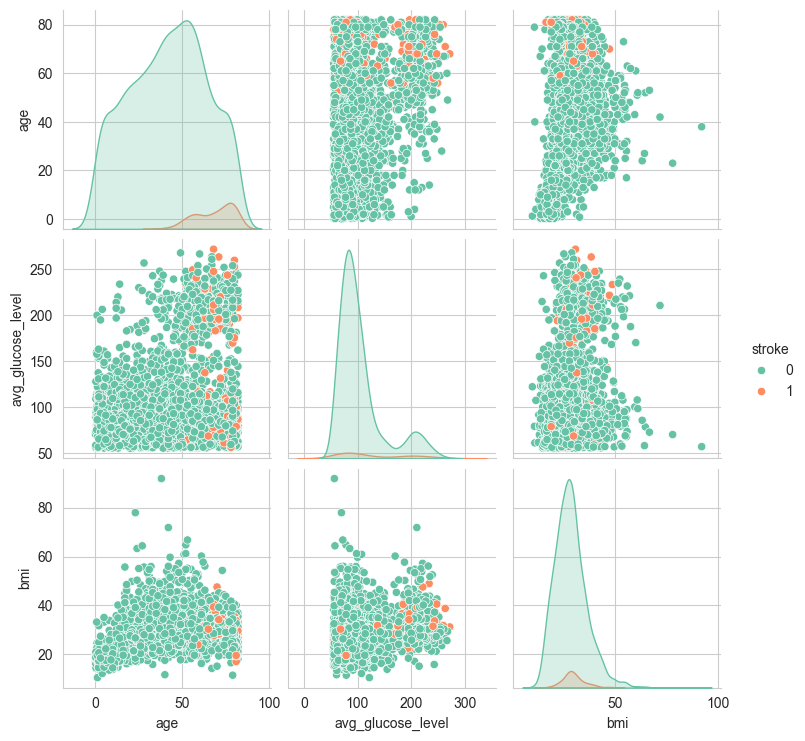

In [130]:
sns.pairplot(
    train_df[["age", "avg_glucose_level", "bmi", "stroke"]],
    hue="stroke",
    diag_kind="kde"
)
plt.show()

### 6.2 Variables categóricas vs target — Chi-cuadrado y V de Cramér


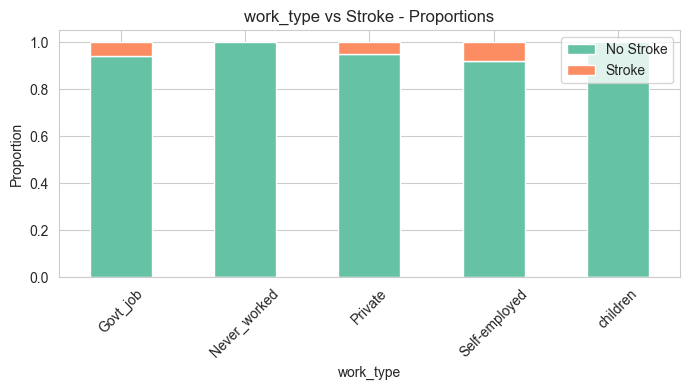

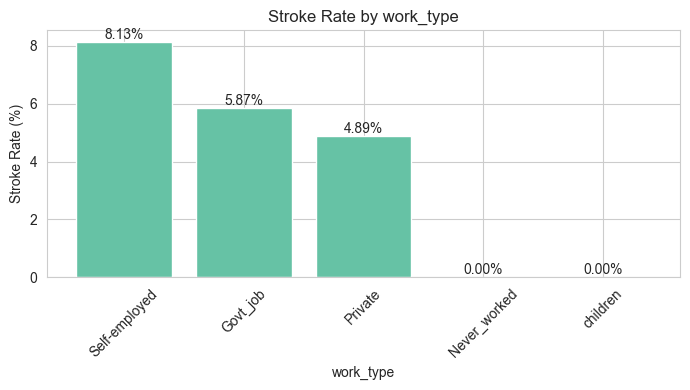

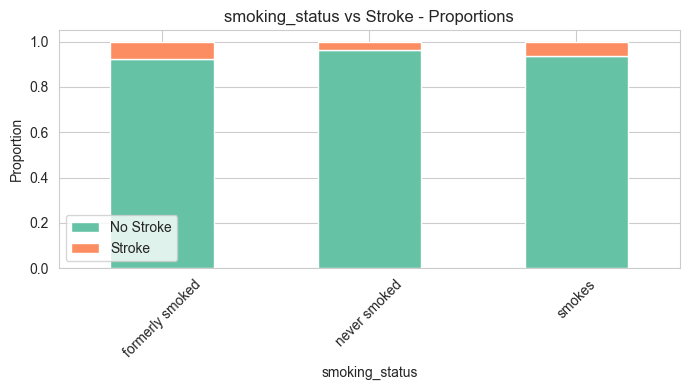

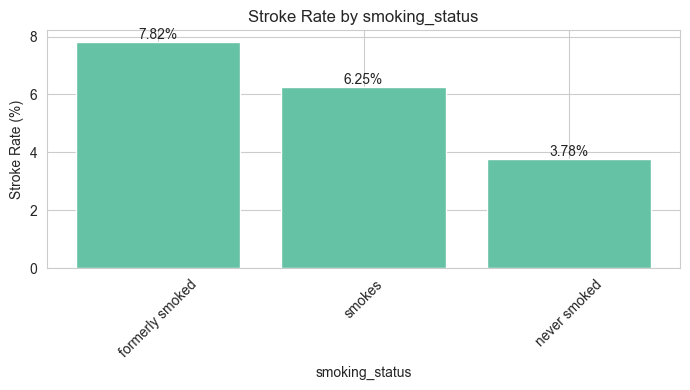

,feature,chi2_p_value,cramers_v
1,smoking_status,1.699897e-04,0.050063
0,work_type,7.800122e-07,0.049410


In [131]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / max((kcorr - 1), (rcorr - 1)))

cat_target_results = []

for col in cat_cols_analysis:
    contingency = pd.crosstab(train_df[col], train_df["stroke"])
    chi2, p, dof, expected = chi2_contingency(contingency)
    cv = cramers_v(train_df[col], train_df["stroke"])

    cat_target_results.append({
        "feature": col,
        "chi2_p_value": p,
        "cramers_v": cv
    })

    prop_table = pd.crosstab(train_df[col], train_df["stroke"], normalize="index")
    prop_table.plot(kind="bar", stacked=True, figsize=(7, 4))
    plt.title(f"{col} vs Stroke - Proportions")
    plt.ylabel("Proportion")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.legend(["No Stroke", "Stroke"])
    plt.tight_layout()
    plt.show()

    rate = train_df.groupby(col)["stroke"].mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(7, 4))
    bars = plt.bar(rate.index.astype(str), rate.values)
    plt.title(f"Stroke Rate by {col}")
    plt.ylabel("Stroke Rate (%)")
    plt.xlabel(col)
    plt.xticks(rotation=45)

    for bar, val in zip(bars, rate.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

cat_target_df = pd.DataFrame(cat_target_results).sort_values(
    by="cramers_v", ascending=False
)

display(cat_target_df)

### 6.3 Matriz de asociación entre variables categóricas


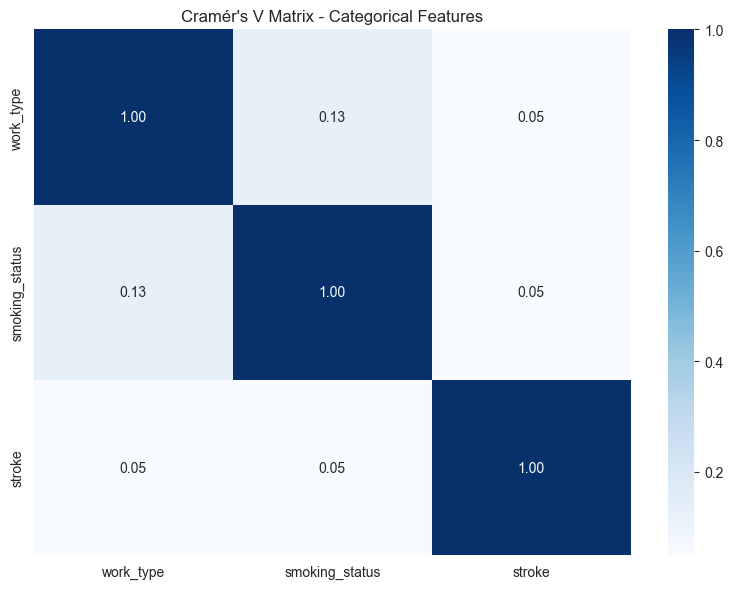

,work_type,smoking_status,stroke
work_type,1.000000,0.134524,0.049410
smoking_status,0.134524,1.000000,0.050063
stroke,0.049410,0.050063,0.996472


In [132]:
cat_all = cat_cols_analysis + ["stroke"]

cramers_matrix = pd.DataFrame(index=cat_all, columns=cat_all, dtype=float)

for col1 in cat_all:
    for col2 in cat_all:
        cramers_matrix.loc[col1, col2] = cramers_v(train_df[col1], train_df[col2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramers_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Cramér's V Matrix - Categorical Features")
plt.tight_layout()
plt.show()

display(cramers_matrix)

### 6.4 Asociación no lineal / no paramétrica: correlación de Spearman


In [133]:
results_spearman = []

for col in ["age", "avg_glucose_level", "bmi"]:
    corr = pd.Series(X_train[col]).corr(y_train, method="spearman")

    results_spearman.append({
        "feature": col,
        "spearman_corr": corr,
        "abs_corr": abs(corr)
    })

spearman_df = pd.DataFrame(results_spearman).sort_values(
    by="abs_corr", ascending=False
)

display(spearman_df)

,feature,spearman_corr,abs_corr
0,age,0.259131,0.259131
1,avg_glucose_level,0.064495,0.064495
2,bmi,0.060456,0.060456


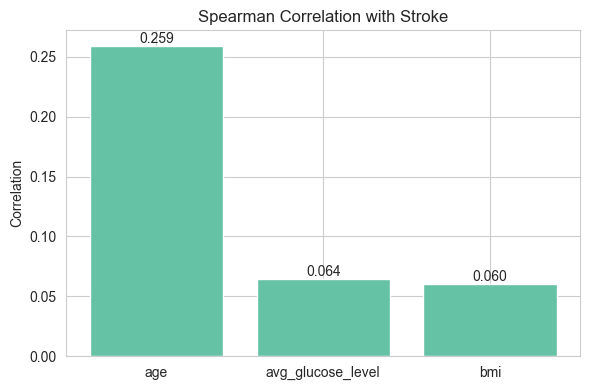

In [134]:
plt.figure(figsize=(6, 4))

bars = plt.bar(spearman_df["feature"], spearman_df["spearman_corr"])

plt.title("Spearman Correlation with Stroke")
plt.ylabel("Correlation")

for bar, val in zip(bars, spearman_df["spearman_corr"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 6.5 Asociación no lineal: información mutua


In [135]:
from sklearn.feature_selection import mutual_info_classif

X_num = X_train[["age", "avg_glucose_level", "bmi"]]

mi = mutual_info_classif(X_num, y_train, random_state=42)

mi_df = pd.DataFrame({
    "feature": X_num.columns,
    "mutual_info": mi
}).sort_values(by="mutual_info", ascending=False)

display(mi_df)

,feature,mutual_info
0,age,0.041557
2,bmi,0.010949
1,avg_glucose_level,0.006615


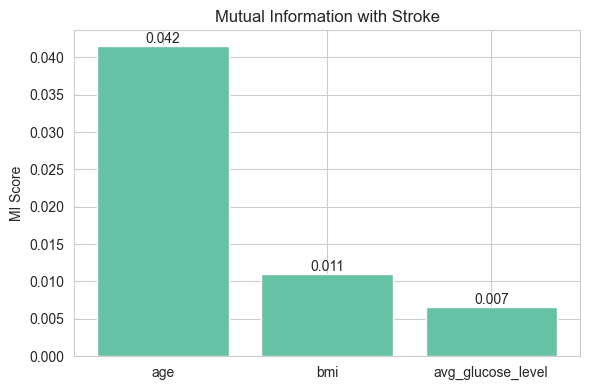

In [136]:
plt.figure(figsize=(6, 4))

bars = plt.bar(mi_df["feature"], mi_df["mutual_info"])

plt.title("Mutual Information with Stroke")
plt.ylabel("MI Score")

for bar, val in zip(bars, mi_df["mutual_info"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{val:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### 6.6 Resumen global de asociación con el target


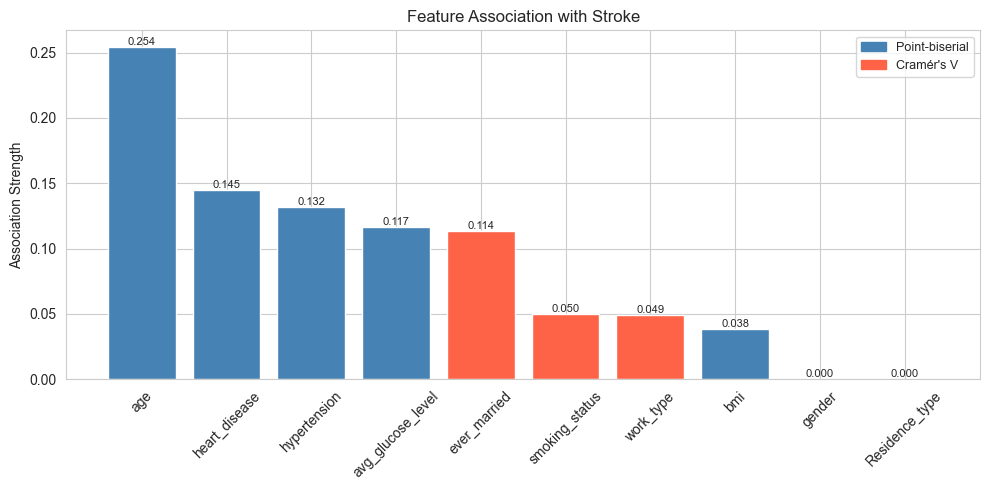

,feature,association_metric,metric_type
0,age,0.254381,Point-biserial
1,heart_disease,0.144807,Point-biserial
0,hypertension,0.131559,Point-biserial
1,avg_glucose_level,0.116566,Point-biserial
1,ever_married,0.113808,Cramér's V
1,smoking_status,0.050063,Cramér's V
0,work_type,0.049410,Cramér's V
2,bmi,0.038154,Point-biserial
0,gender,0.000000,Cramér's V
2,Residence_type,0.000000,Cramér's V


In [137]:
from scipy.stats import pointbiserialr

# Point-biserial para numéricas
num_results = []
for col in num_cols:
    r, p = pointbiserialr(train_df["stroke"], train_df[col])
    num_results.append({"feature": col, "association_metric": abs(r), "metric_type": "Point-biserial"})

# Point-biserial para binarias (ya numéricas)
bin_results = []
for col in bin_cols_analysis:
    r, p = pointbiserialr(train_df["stroke"], train_df[col])
    bin_results.append({"feature": col, "association_metric": abs(r), "metric_type": "Point-biserial"})

# Cramér's V para binarias string (gender, ever_married, Residence_type)
str_bin_results = []
for col in str_bin_cols:
    cv = cramers_v(train_df[col], train_df["stroke"])
    str_bin_results.append({"feature": col, "association_metric": cv, "metric_type": "Cramér's V"})

# Cramér's V para categóricas (ya calculado en cat_target_df)
cat_results = cat_target_df[["feature", "cramers_v"]].copy()
cat_results = cat_results.rename(columns={"cramers_v": "association_metric"})
cat_results["metric_type"] = "Cramér's V"

global_summary = pd.concat([
    pd.DataFrame(num_results),
    pd.DataFrame(bin_results),
    pd.DataFrame(str_bin_results),
    cat_results[["feature", "association_metric", "metric_type"]]
], axis=0).sort_values(by="association_metric", ascending=False)

plt.figure(figsize=(10, 5))
colors = ["steelblue" if m == "Point-biserial" else "tomato"
          for m in global_summary["metric_type"]]
bars = plt.bar(global_summary["feature"], global_summary["association_metric"], color=colors)
plt.title("Feature Association with Stroke")
plt.ylabel("Association Strength")
plt.xticks(rotation=45)
for bar, val in zip(bars, global_summary["association_metric"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color="steelblue", label="Point-biserial"),
    plt.Rectangle((0,0),1,1, color="tomato", label="Cramér's V")
], fontsize=9)
plt.tight_layout()
plt.show()

display(global_summary)

## 7. Encoding y construcción de las matrices procesadas


In [138]:
# Eliminar fila con gender="Other" (1 observacion en todo el dataset)
mask_train = X_train["gender"] != "Other"
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test["gender"] != "Other"
X_test = X_test[mask_test]
y_test = y_test[mask_test]

mask_val = X_val["gender"] != "Other"
X_val = X_val[mask_val]
y_val = y_val[mask_val]

print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas | Val: {X_val.shape[0]} filas")


Train: 3065 filas | Test: 1022 filas | Val: 1022 filas


In [139]:
# Gender encoding
gender_map = {"Male": 0, "Female": 1}
X_train["gender"] = X_train["gender"].map(gender_map)
X_test["gender"]  = X_test["gender"].map(gender_map)
X_val["gender"]   = X_val["gender"].map(gender_map)

# Ever married encoding
married_map = {"Yes": 1, "No": 0}
X_train["ever_married"] = X_train["ever_married"].map(married_map)
X_test["ever_married"]  = X_test["ever_married"].map(married_map)
X_val["ever_married"]   = X_val["ever_married"].map(married_map)

# Residence type encoding
residence_map = {"Urban": 1, "Rural": 0}
X_train["Residence_type"] = X_train["Residence_type"].map(residence_map)
X_test["Residence_type"]  = X_test["Residence_type"].map(residence_map)
X_val["Residence_type"]   = X_val["Residence_type"].map(residence_map)


In [140]:
# Verificar categorías de work_type
print("work_type categories:")
print(X_train["work_type"].value_counts())

work_type categories:
work_type
Private          1757
Self-employed     492
children          412
Govt_job          392
Never_worked       12
Name: count, dtype: int64


In [141]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = [
    "work_type",
    "smoking_status",
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=int, drop='first')

# Fit solo en train
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# Transform en test y val
X_test_encoded = encoder.transform(X_test[cat_cols])
X_val_encoded  = encoder.transform(X_val[cat_cols])


In [142]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_cols,
    index=X_val.index
)

display(X_train_encoded.head())


,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,0,1,0,0,1,0
3455,0,0,0,0,1,0
1438,0,1,0,0,1,0
1566,0,0,1,0,1,0
4182,0,1,0,0,1,0


In [143]:
num_cols_model = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease", "gender", "ever_married", "Residence_type"]

X_train_final = pd.concat(
    [X_train[num_cols_model + bin_cols], X_train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test[num_cols_model + bin_cols], X_test_encoded],
    axis=1
)

X_val_final = pd.concat(
    [X_val[num_cols_model + bin_cols], X_val_encoded],
    axis=1
)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape: ", X_test_final.shape)
print("X_val_final shape:  ", X_val_final.shape)
display(X_train_final.head())


X_train_final shape: (3065, 14)
X_test_final shape:  (1022, 14)
X_val_final shape:   (1022, 14)


,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,1,0,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,1,0,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,1,0,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,1,0,0,1,0


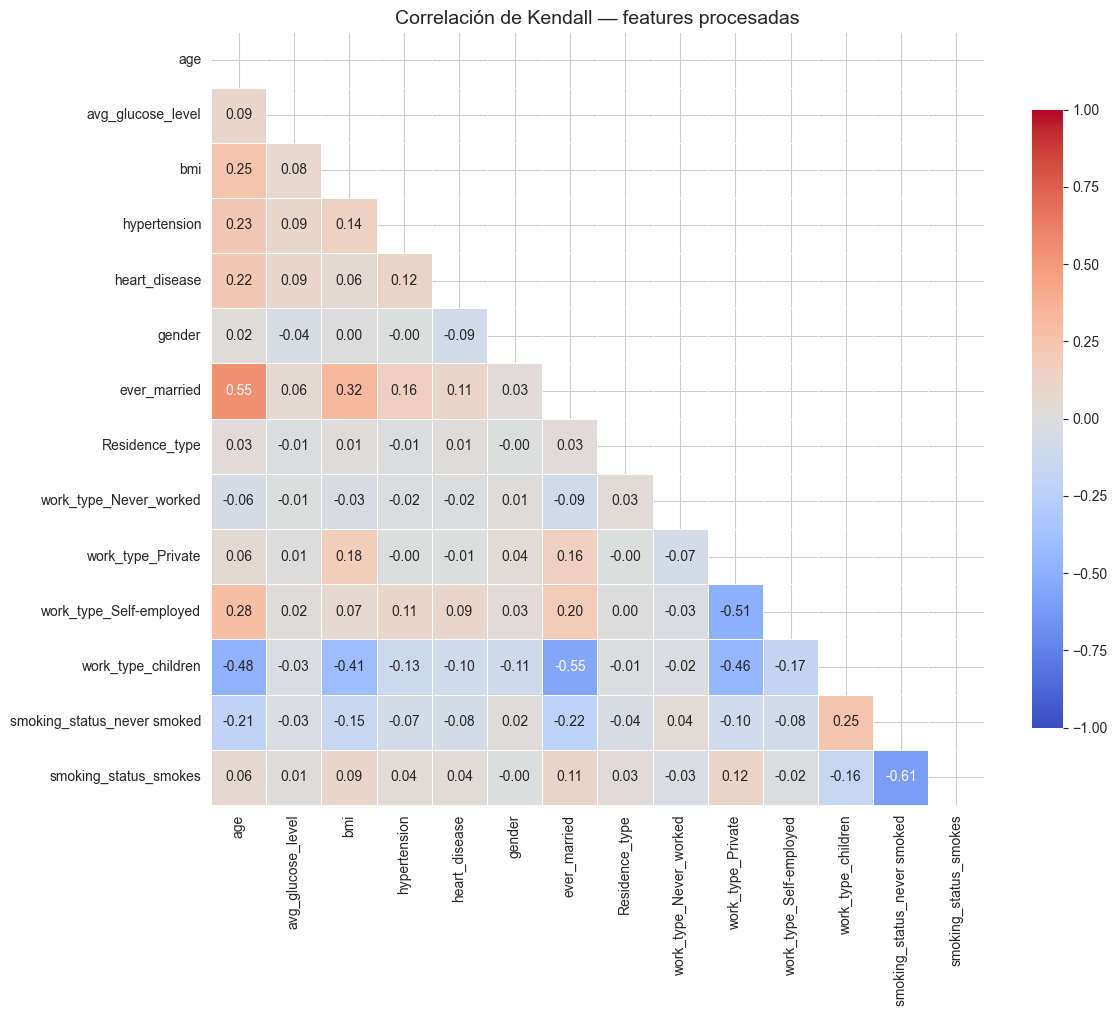

In [144]:
# Heatmap de correlación de Kendall sobre el dataset procesado
corr_kendall = X_train_final.corr(method="kendall")

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_kendall, dtype=bool))
sns.heatmap(
    corr_kendall,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlación de Kendall — features procesadas", fontsize=14)
plt.tight_layout()
plt.show()

In [145]:
print("Missing values in processed matrices:")
print("Train:", X_train_final.isnull().sum().sum())
print("Test: ", X_test_final.isnull().sum().sum())
print("Val:  ", X_val_final.isnull().sum().sum())


Missing values in processed matrices:
Train: 0
Test:  0
Val:   0


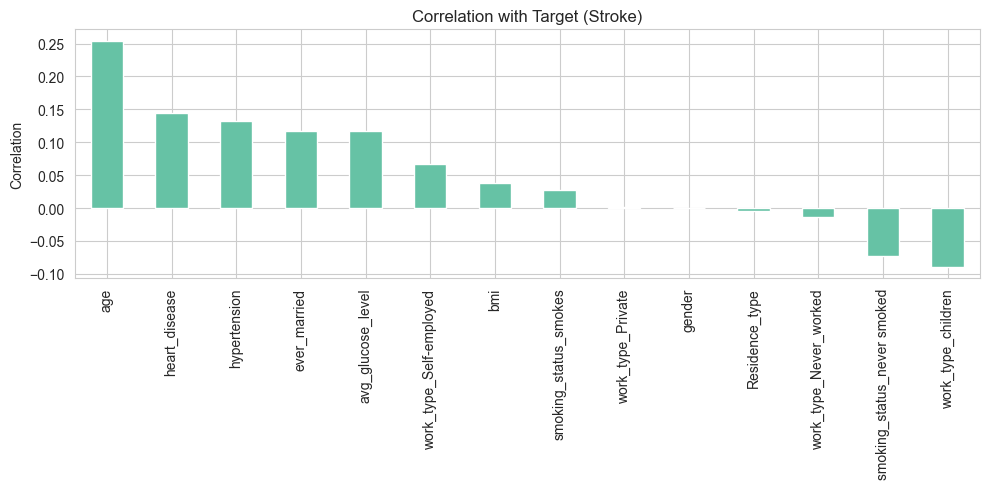

stroke                         1.000000
age                            0.254351
heart_disease                  0.144792
hypertension                   0.131539
ever_married                   0.116752
avg_glucose_level              0.116641
work_type_Self-employed        0.066464
bmi                            0.038098
smoking_status_smokes          0.027273
work_type_Private              0.001798
gender                        -0.000654
Residence_type                -0.004478
work_type_Never_worked        -0.014172
smoking_status_never smoked   -0.072439
work_type_children            -0.089080
Name: stroke, dtype: float64

In [146]:
df_corr = X_train_final.copy()
df_corr["stroke"] = y_train

corr_with_target = df_corr.corr()["stroke"].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
corr_with_target.drop("stroke").plot(kind="bar")
plt.title("Correlation with Target (Stroke)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

display(corr_with_target)

In [147]:
X_train_final.to_csv('../datasets/X_train.csv', index=False)
X_test_final.to_csv('../datasets/X_test.csv',  index=False)
X_val_final.to_csv('../datasets/X_val.csv',    index=False)
y_train.to_csv('../datasets/y_train.csv',      index=False)
y_test.to_csv('../datasets/y_test.csv',        index=False)
y_val.to_csv('../datasets/y_val.csv',          index=False)


In [148]:
X_train_final

,age,avg_glucose_level,bmi,hypertension,heart_disease,gender,ever_married,Residence_type,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_never smoked,smoking_status_smokes
3135,44.0,84.10,30.2,1,0,0,1,0,0,1,0,0,1,0
3455,75.0,223.14,27.8,0,0,0,1,1,0,0,0,0,1,0
1438,47.0,93.55,31.4,0,0,0,1,0,0,1,0,0,1,0
1566,76.0,101.43,29.1,0,1,0,1,0,0,0,1,0,1,0
4182,28.0,104.16,21.5,0,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,40.0,114.32,28.3,0,0,1,1,1,0,0,0,0,0,1
1434,45.0,92.86,35.1,0,0,1,1,1,0,1,0,0,0,0
461,16.0,113.47,19.5,0,0,1,0,0,0,0,0,1,1,0
1052,61.0,78.65,36.2,0,0,1,1,0,0,1,0,0,0,0


## 8. Escalado para los modelos


In [149]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["age", "avg_glucose_level", "bmi"]

preprocessor = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), num_cols)],
    remainder="passthrough"
)

X_train_scaled = preprocessor.fit_transform(X_train_final)
X_test_scaled  = preprocessor.transform(X_test_final)
X_val_scaled   = preprocessor.transform(X_val_final)

print("Scaling completed.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape: ", X_test_scaled.shape)
print("X_val_scaled shape:  ", X_val_scaled.shape)


Scaling completed.
X_train_scaled shape: (3065, 14)
X_test_scaled shape:  (1022, 14)
X_val_scaled shape:   (1022, 14)


In [150]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_final.columns)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test_final.columns)
X_val_scaled_df   = pd.DataFrame(X_val_scaled,   columns=X_val_final.columns)

print(X_train_scaled_df.head())


        age  avg_glucose_level       bmi  hypertension  heart_disease  gender  \
0  0.038722          -0.482734  0.177019           1.0            0.0     0.0   
1  1.423515           2.608955 -0.132442           0.0            0.0     0.0   
2  0.172734          -0.272604  0.331749           0.0            0.0     0.0   
3  1.468186          -0.097385  0.035182           0.0            1.0     0.0   
4 -0.676010          -0.036681 -0.944776           0.0            0.0     1.0   

   ever_married  Residence_type  work_type_Never_worked  work_type_Private  \
0           1.0             0.0                     0.0                1.0   
1           1.0             1.0                     0.0                0.0   
2           1.0             0.0                     0.0                1.0   
3           1.0             0.0                     0.0                0.0   
4           0.0             0.0                     0.0                1.0   

   work_type_Self-employed  work_type_childr

In [151]:
import joblib
import os
os.makedirs("../data", exist_ok=True)

# guardar datos procesados (3 splits: train / test / val)
joblib.dump({
    "X_train": X_train_scaled,
    "X_test":  X_test_scaled,
    "X_val":   X_val_scaled,
    "y_train": y_train,
    "y_test":  y_test,
    "y_val":   y_val,
    "feature_names": list(X_train_final.columns)
}, "../data/processed_data.pkl")

print("Datos exportados a data/processed_data.pkl")
print(f"X_train: {X_train_scaled.shape} | X_test: {X_test_scaled.shape} | X_val: {X_val_scaled.shape}")
print(f"Features: {list(X_train_final.columns)}")


Datos exportados a data/processed_data.pkl
X_train: (3065, 14) | X_test: (1022, 14) | X_val: (1022, 14)
Features: ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'gender', 'ever_married', 'Residence_type', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_never smoked', 'smoking_status_smokes']


## 9. Resumen

Este notebook contiene el mismo contenido analítico que el flujo original, presentado en un orden más estructurado:
1. Carga de datos y split.
2. EDA sobre el set de entrenamiento.
3. Análisis de valores faltantes y categoría `"Unknown"`.
4. Preprocesamiento seguro contra *leakage*.
5. Matrices encodificadas y escaladas listas para modelado.
6. Análisis de correlación y asociación con múltiples métricas complementarias.
